# Part II: Vision Task - EuroSAT Image Classification
## Herald College Kathmandu | 6CS012 - Artificial Intelligence and Machine Learning
## Final Portfolio Assessment 2026

This notebook contains my implementation for the vision part of the assessment. The task is to classify EuroSAT satellite images into 10 land-use classes. I trained a baseline CNN from scratch, improved it with a deeper regularised CNN, compared optimizers and an ablation setting, and then fine-tuned a ResNet50 transfer-learning model.


# Part II: Vision Task - EuroSAT

In [1]:
import os

_candidates = [
    "/mnt/d/IT/it2026 6th sem/ml ai/assesment/EuroSAT",
    r"D:\IT\it2026 6th sem\ml ai\assesment\EuroSAT",
    "/content/drive/MyDrive/AI ML/collab/euro/EuroSAT",
    "./EuroSAT",
]
DATA_ROOT = next((p for p in _candidates if os.path.isdir(p)), None)
assert DATA_ROOT, f"EuroSAT folder not found. Tried: {_candidates}"
print("Dataset root:", DATA_ROOT)
print("Files:", sorted(os.listdir(DATA_ROOT))[:15], "...")


Dataset root: ./EuroSAT
Files: ['.sixth', 'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'label_map.json', 'test.csv', 'train.csv', 'validation.csv'] ...


In [2]:
%pip install -q scikit-learn seaborn matplotlib nltk wordcloud gensim gradio

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from collections import Counter
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print(f"TensorFlow version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected     : {gpus[0].name}")
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
else:
    print("⚠️  No GPU detected — training will be slower. "
          "Make sure the VS Code kernel is 'eurosat-gpu' (the venv with tensorflow[and-cuda]).")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print("\n✅ Environment ready.")


Note: you may need to restart the kernel to use updated packages.


2026-05-10 05:54:11.507015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 05:54:11.609376: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 05:54:11.640841: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 05:54:11.840764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 05:54:14.585575: W tensorflow/compiler/tf2

TensorFlow version : 2.17.1
✅ GPU detected     : /physical_device:GPU:0

✅ Environment ready.


I0000 00:00:1778392461.189169    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392461.519746    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392461.520029    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPUs visible:", gpus)
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print("Memory growth: ON")
else:
    print("No GPU — kernel is not pointing at the eurosat-gpu venv, "
          "or the WSL/NVIDIA driver chain is broken (run `nvidia-smi`).")


TensorFlow: 2.17.1
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth: ON


In [4]:
import os
print("cwd:", os.getcwd())
print("DATA_ROOT:", DATA_ROOT)
print("EuroSAT exists:", os.path.exists(DATA_ROOT))
print("label_map exists:", os.path.exists(f"{DATA_ROOT}/label_map.json"))
print("files in EuroSAT:", os.listdir(DATA_ROOT)[:20] if os.path.exists(DATA_ROOT) else "missing folder")


cwd: /mnt/c/Users/suwal/OneDrive/Documents/6th sem/ai/assensmet
DATA_ROOT: ./EuroSAT
EuroSAT exists: True
label_map exists: True
files in EuroSAT: ['.sixth', 'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'label_map.json', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'test.csv', 'train.csv', 'validation.csv']


## 2.5.1 Data Understanding, Analysis, Visualization and Cleaning

The dataset used here is EuroSAT, a remote-sensing image dataset built from Sentinel-2 satellite imagery. It contains 27,000 RGB images of size 64 x 64, grouped into 10 land-use classes: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, and SeaLake.

The data is already split using CSV files: 18,900 images for training, 5,400 for validation, and 2,700 for testing. This gives a 70/20/10 split, which leaves enough data for model fitting while keeping separate validation and test sets for fair comparison. The class distribution is close to balanced, ranging from 2,000 to 3,000 images per class, so I did not add class weighting.

For preprocessing, the images are normalized from pixel values 0-255 to the range 0-1. On the training set I used augmentation such as horizontal and vertical flips, 90-degree rotations, brightness changes, contrast changes, saturation changes, and hue changes. These transformations are suitable for satellite patches because the same land-use class can appear in different orientations and lighting conditions.


In [5]:
import json

with open(f"{DATA_ROOT}/label_map.json") as f:
    label_map = json.load(f)

CLASS_NAMES  = [name for name, _ in sorted(label_map.items(),
                                           key=lambda kv: kv[1])]
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SHAPE    = (64, 64, 3)

train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
val_df   = pd.read_csv(f"{DATA_ROOT}/validation.csv")
test_df  = pd.read_csv(f"{DATA_ROOT}/test.csv")
all_df   = pd.concat([train_df, val_df, test_df], ignore_index=True)

TOTAL_IMAGES = len(all_df)

AUTOTUNE = tf.data.AUTOTUNE

def _load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = tf.cast(img, tf.uint8)
    return img, label

def df_to_ds(df):
    paths  = (DATA_ROOT + '/' + df['Filename'].astype(str)).values
    labels = df['Label'].astype(int).values
    return (tf.data.Dataset
              .from_tensor_slices((paths, labels))
              .map(_load_image, num_parallel_calls=AUTOTUNE))

raw_train_ds = df_to_ds(all_df)

print("\n" + "═"*55)
print("  EUROSAT DATASET – OVERVIEW")
print("═"*55)
print(f"  Description : Remote-sensing land-use classification")
print(f"  Source      : Sentinel-2 satellite imagery (ESA) – local copy")
print(f"  Path        : {DATA_ROOT}")
print(f"  Total images: {TOTAL_IMAGES:,}")
print(f"    train.csv      : {len(train_df):,}")
print(f"    validation.csv : {len(val_df):,}")
print(f"    test.csv       : {len(test_df):,}")
print(f"  Classes     : {NUM_CLASSES}")
print(f"  Image shape : {IMG_SHAPE}  (H × W × C)")
print(f"  Labels      : {CLASS_NAMES}")
print("═"*55)



═══════════════════════════════════════════════════════
  EUROSAT DATASET – OVERVIEW
═══════════════════════════════════════════════════════
  Description : Remote-sensing land-use classification
  Source      : Sentinel-2 satellite imagery (ESA) – local copy
  Path        : ./EuroSAT
  Total images: 27,000
    train.csv      : 18,900
    validation.csv : 5,400
    test.csv       : 2,700
  Classes     : 10
  Image shape : (64, 64, 3)  (H × W × C)
  Labels      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
═══════════════════════════════════════════════════════


I0000 00:00:1778392461.714216    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392461.714382    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392461.714465    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392462.239240    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1778392462.239379    8162 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10

Counting class distribution (scans the full dataset) …


2026-05-10 05:54:47.977313: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Class ID  Class Name                  Count    % of total
---------------------------------------------------------
  0       AnnualCrop                   3000     11.11%
  1       Forest                       3000     11.11%
  2       HerbaceousVegetation         3000     11.11%
  3       Highway                      2500      9.26%
  4       Industrial                   2500      9.26%
  5       Pasture                      2000      7.41%
  6       PermanentCrop                2500      9.26%
  7       Residential                  3000     11.11%
  8       River                        2500      9.26%
  9       SeaLake                      3000     11.11%
---------------------------------------------------------
  TOTAL                               27000    100.00%


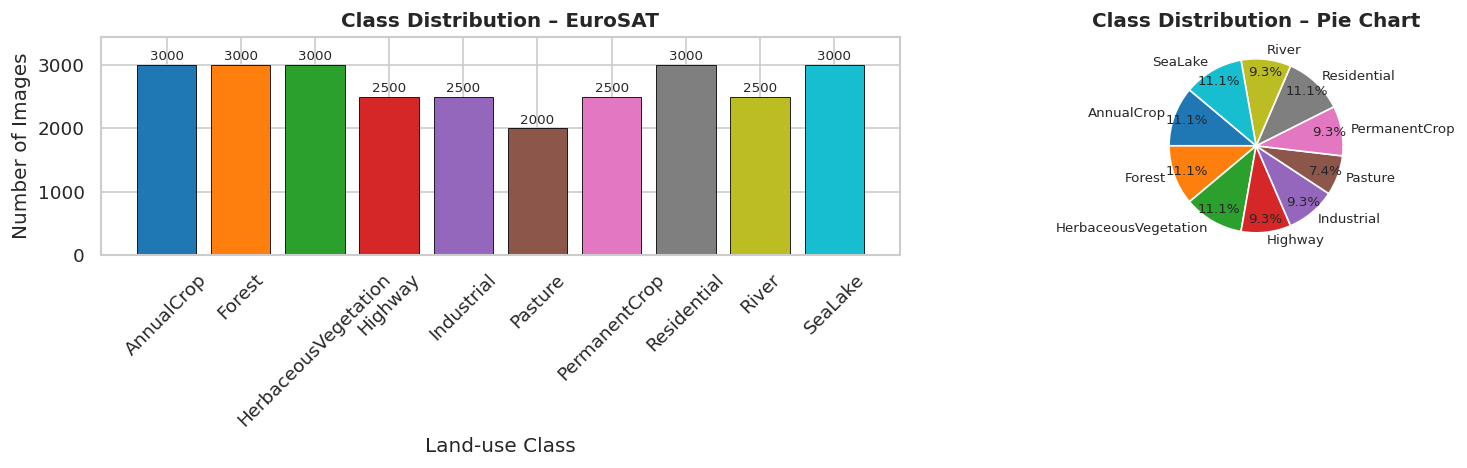


 Observation: The dataset is BALANCED — each class has ~2700 images. No class imbalance handling needed.


In [6]:
print("Counting class distribution (scans the full dataset) …")

label_counter = Counter()
for _, label in raw_train_ds:
    label_counter[int(label.numpy())] += 1

counts = [label_counter[i] for i in range(NUM_CLASSES)]

print(f"\n{'Class ID':<10}{'Class Name':<26}{'Count':>7}{'  % of total':>14}")
print("-"*57)
for i, (name, cnt) in enumerate(zip(CLASS_NAMES, counts)):
    pct = cnt / TOTAL_IMAGES * 100
    print(f"  {i:<8}{name:<26}{cnt:>7}    {pct:>6.2f}%")
print("-"*57)
print(f"  {'TOTAL':<34}{TOTAL_IMAGES:>7}    100.00%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = sns.color_palette('tab10', NUM_CLASSES)

axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution – EuroSAT', fontweight='bold')
axes[0].set_xlabel('Land-use Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(cnt), ha='center', va='bottom', fontsize=8)

axes[1].pie(counts, labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.85, textprops={'fontsize': 8})
axes[1].set_title('Class Distribution – Pie Chart', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Observation: The dataset is BALANCED — each class has "
      f"~{TOTAL_IMAGES // NUM_CLASSES} images. No class imbalance handling needed.")


Computing pixel statistics on a 5% sample …


2026-05-10 05:54:49.786050: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Red   – mean: 87.1  std: 51.2  min: 9  max: 255
  Green – mean: 97.3  std: 34.2  min: 28  max: 255
  Blue  – mean: 102.8  std: 29.0  min: 37  max: 255


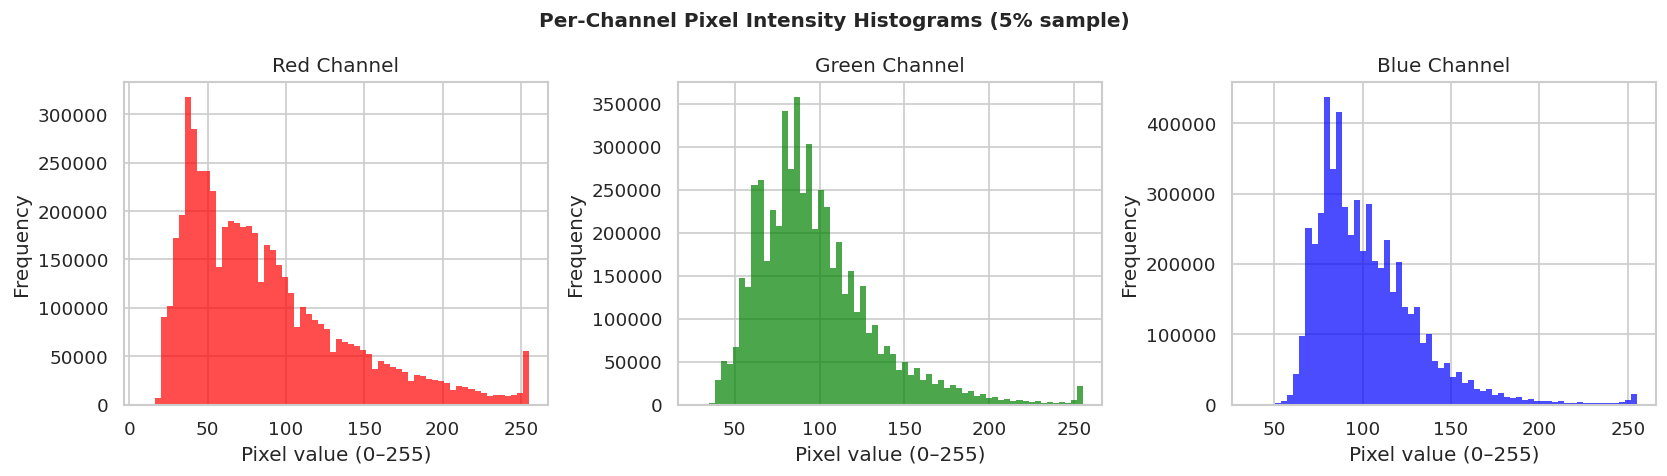


📌 Observation: Pixel values range 0–255. We will normalise to [0, 1] before training.


In [7]:
print("Computing pixel statistics on a 5% sample …")

sample_images = []
for img, _ in raw_train_ds.take(1350):
    sample_images.append(img.numpy())
sample_array = np.array(sample_images)

ch_names = ['Red', 'Green', 'Blue']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Per-Channel Pixel Intensity Histograms (5% sample)', fontweight='bold')

for ch, (ax, cname, col) in enumerate(zip(axes, ch_names, ['red', 'green', 'blue'])):
    flat = sample_array[:, :, :, ch].ravel()
    ax.hist(flat, bins=64, color=col, alpha=0.7, edgecolor='none')
    ax.set_title(f'{cname} Channel')
    ax.set_xlabel('Pixel value (0–255)')
    ax.set_ylabel('Frequency')
    print(f"  {cname:5s} – mean: {flat.mean():.1f}  std: {flat.std():.1f}  "
          f"min: {flat.min()}  max: {flat.max()}")

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('pixel_stats.png', 'wb') as _f: _f.write(_buf.read())
plt.show()

print("\n📌 Observation: Pixel values range 0–255. "
      "We will normalise to [0, 1] before training.")


In [8]:
IMG_SIZE   = 64
BATCH_SIZE = 32

TRAIN_N = len(train_df)
VAL_N   = len(val_df)
TEST_N  = len(test_df)

print('Dataset split (from CSVs):')
print(f'  Training   : {TRAIN_N:>6,}  images  ({TRAIN_N/TOTAL_IMAGES:.0%})')
print(f'  Validation : {VAL_N:>6,}  images  ({VAL_N/TOTAL_IMAGES:.0%})')
print(f'  Test       : {TEST_N:>6,}  images  ({TEST_N/TOTAL_IMAGES:.0%})')

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    image = tf.image.random_brightness(image, max_delta=0.25)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

train_ds_raw = df_to_ds(train_df).shuffle(2048, seed=SEED,
                                          reshuffle_each_iteration=True)
val_ds_raw   = df_to_ds(val_df)
test_ds_raw  = df_to_ds(test_df)

train_ds = (train_ds_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .map(augment,    num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (val_ds_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (test_ds_raw
            .map(preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('\n tf.data pipelines built with:')
print('   • Normalisation (÷255) on all splits')
print('   • Enhanced augmentation on training split:')
print('     – Random horizontal & vertical flip')
print('     – Random 90° rotation (k=0,1,2,3)')
print('     – Random brightness (±0.25)')
print('     – Random contrast (0.75–1.25)')
print('     – Random saturation (0.8–1.2)')
print('     – Random hue (±0.05)')


Dataset split (from CSVs):
  Training   : 18,900  images  (70%)
  Validation :  5,400  images  (20%)
  Test       :  2,700  images  (10%)

 tf.data pipelines built with:
   • Normalisation (÷255) on all splits
   • Enhanced augmentation on training split:
     – Random horizontal & vertical flip
     – Random 90° rotation (k=0,1,2,3)
     – Random brightness (±0.25)
     – Random contrast (0.75–1.25)
     – Random saturation (0.8–1.2)
     – Random hue (±0.05)


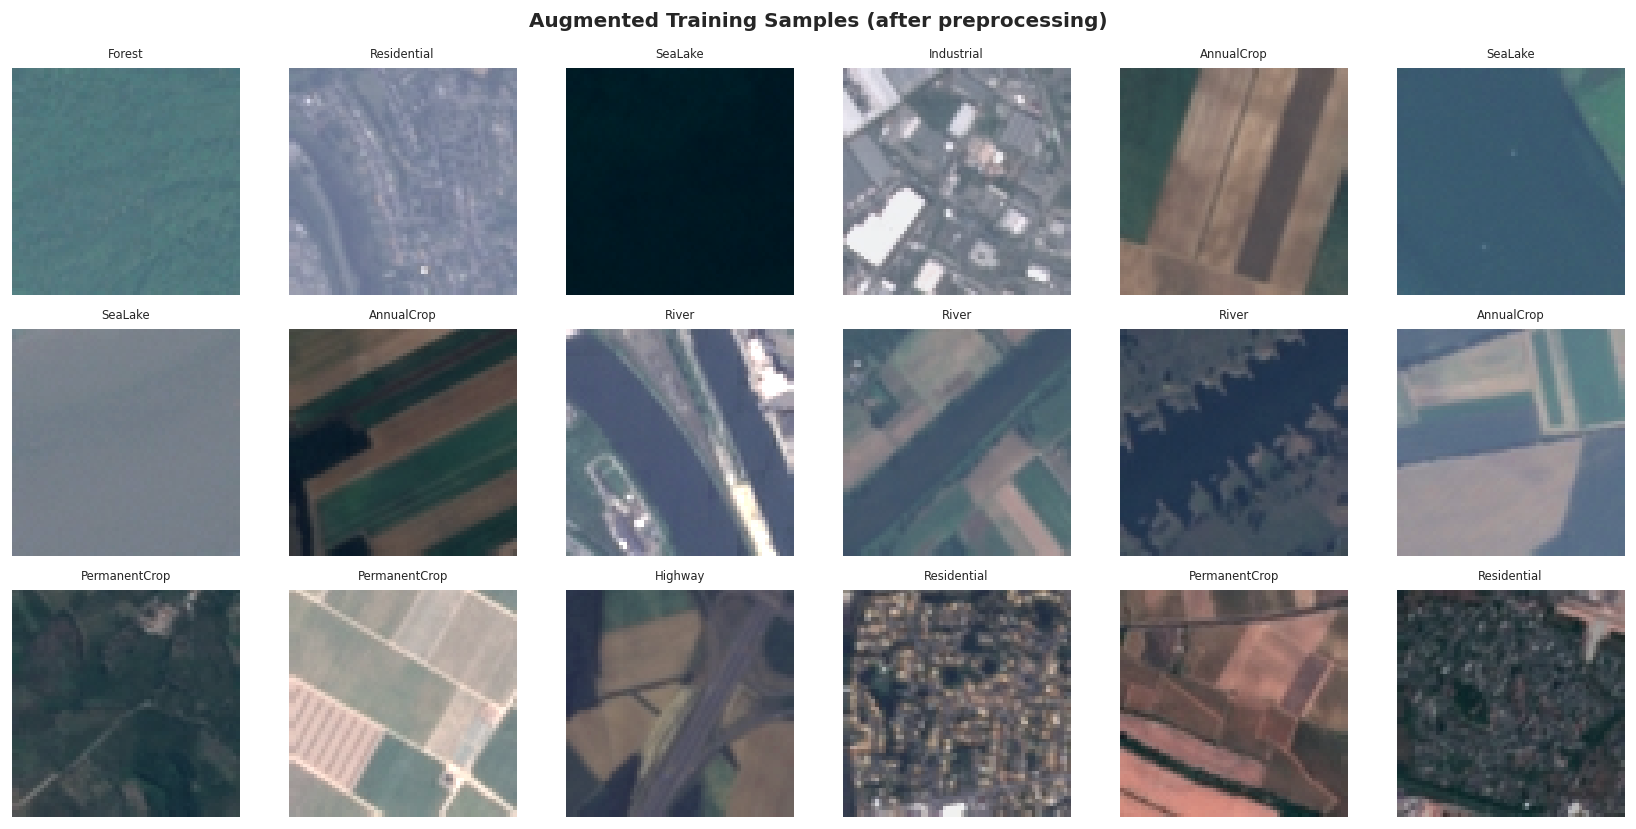

📌 Images are normalised to [0,1]; augmentation adds visual diversity 
   to help the model generalise better to unseen satellite patches.


In [9]:
for imgs, labels in train_ds.take(1):
    batch_imgs   = imgs.numpy()
    batch_labels = labels.numpy()

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
axes = axes.flatten()
fig.suptitle('Augmented Training Samples (after preprocessing)',
             fontsize=12, fontweight='bold')

for i in range(18):
    axes[i].imshow(batch_imgs[i])
    axes[i].set_title(CLASS_NAMES[batch_labels[i]], fontsize=7)
    axes[i].axis('off')

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('augmented_samples.png', 'wb') as _f: _f.write(_buf.read())
plt.show()

print("📌 Images are normalised to [0,1]; augmentation adds visual diversity ")
print("   to help the model generalise better to unseen satellite patches.")


## 2.5.2 Baseline CNN Model

For the baseline model I used three convolution blocks. Each block has a 3 x 3 convolution followed by max pooling. The number of filters increases from 32 to 64 to 128 so that earlier layers learn simple patterns such as edges and colour changes, while later layers learn stronger texture and land-shape features. ReLU is used because it is simple and works well for CNN training.

After the convolution blocks, the feature maps are flattened and passed through three fully connected layers with 256, 128, and 64 units. The final dense layer has 10 softmax outputs, one for each EuroSAT class. The model has 2,232,458 trainable parameters. Dropout is included in the dense part to reduce memorisation.

The baseline reached 89.00% test accuracy with weighted precision 0.8933, recall 0.8900, and F1-score 0.8901. The best validation accuracy was 0.8833 at epoch 22. The training and validation curves stayed close, so the baseline did not show serious overfitting.


In [10]:
from tensorflow.keras import layers, models, regularizers

def build_baseline_cnn(input_shape=(64, 64, 3), num_classes=10):
    model = models.Sequential(name='Baseline_CNN')

    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape,
                            name='conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same', name='conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))

    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.3, name='dropout1'))
    model.add(layers.Dense(128, activation='relu', name='fc2'))
    model.add(layers.Dropout(0.3, name='dropout2'))
    model.add(layers.Dense(64,  activation='relu', name='fc3'))

    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,458 (8.52 MB)

 Trainable params: 2,232,458 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from IPython.display import Image, display

def show_model_diagram(model):
    try:
        dot = tf.keras.utils.model_to_dot(
            model,
            show_shapes=True,
            show_layer_names=True,
            dpi=80,
        )
        png_bytes = dot.create_png()
        display(Image(data=png_bytes))
    except Exception as _e:
        print(f'Architecture diagram unavailable ({type(_e).__name__}: {_e}).'
              '  Model summary printed above.')

show_model_diagram(baseline_model)


Architecture diagram unavailable (ImportError: You must install pydot (`pip install pydot`) for model_to_dot to work.).  Model summary printed above.


In [12]:
EPOCHS_BASELINE = 25

callbacks_baseline = [

    tf.keras.callbacks.ModelCheckpoint(
        'best_baseline.weights.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0, save_weights_only=True
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

print(f"Training Baseline CNN for up to {EPOCHS_BASELINE} epochs …")
t0 = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    epochs=EPOCHS_BASELINE,
    validation_data=val_ds,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_training_time = time.time() - t0
print(f"\n⏱️  Baseline training time: {baseline_training_time/60:.1f} minutes")


Training Baseline CNN for up to 25 epochs …
Epoch 1/25


I0000 00:00:1778392506.104530    8438 service.cc:146] XLA service 0x7ff7fc00df00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778392506.104613    8438 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-05-10 05:55:06.242691: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-10 05:55:06.800620: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  7/591 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.0835 - loss: 2.3199 

I0000 00:00:1778392513.995481    8438 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.3421 - loss: 1.6776 - val_accuracy: 0.5578 - val_loss: 1.1737 - learning_rate: 0.0010
Epoch 2/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.5364 - loss: 1.2195 - val_accuracy: 0.6443 - val_loss: 0.9484 - learning_rate: 0.0010
Epoch 3/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.6329 - loss: 1.0175 - val_accuracy: 0.6815 - val_loss: 0.8388 - learning_rate: 0.0010
Epoch 4/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.6711 - loss: 0.9168 - val_accuracy: 0.7396 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 5/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.7126 - loss: 0.8146 - val_accuracy: 0.7750 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 6/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.7338 - loss: 0.7482 - val_accuracy: 0.7970 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 7/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.7495 - loss: 0.7034

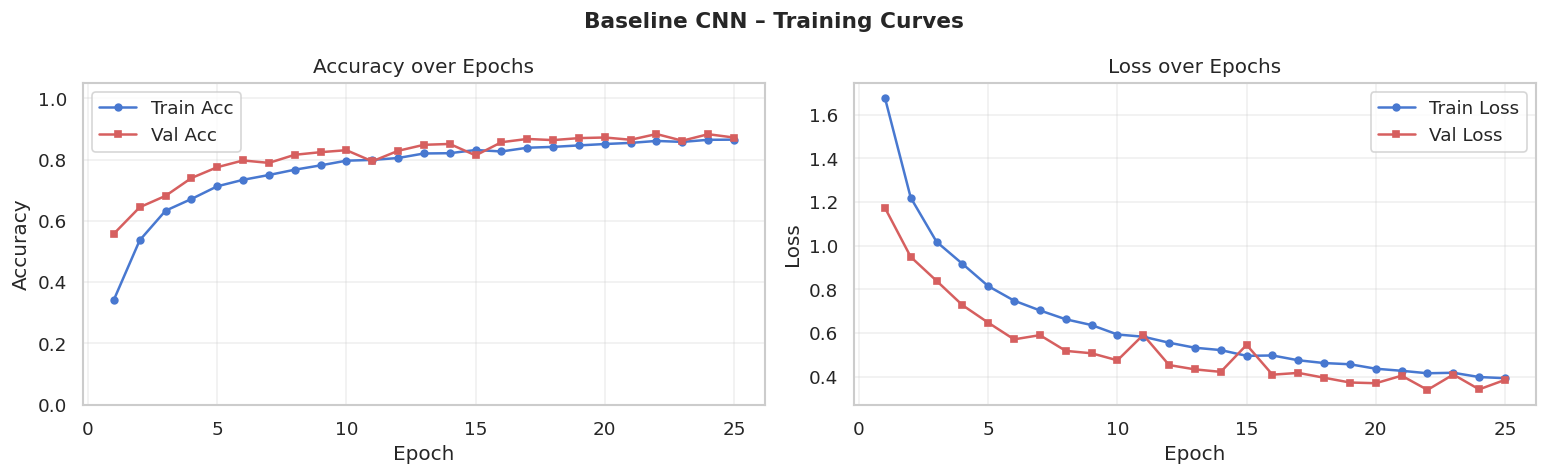

  Best val_accuracy : 0.8833  (epoch 22)
  Final train_acc   : 0.8650
  Train–Val gap     : -0.0069  (well generalised)


In [13]:
def plot_training_curves(history, title='Training Curves', save_as=None):
    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.plot(epochs_ran, history.history['accuracy'],    'b-o', label='Train Acc',  markersize=4)
    ax1.plot(epochs_ran, history.history['val_accuracy'],'r-s', label='Val Acc',    markersize=4)
    ax1.set_title('Accuracy over Epochs')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    ax2.plot(epochs_ran, history.history['loss'],    'b-o', label='Train Loss', markersize=4)
    ax2.plot(epochs_ran, history.history['val_loss'],'r-s', label='Val Loss',   markersize=4)
    ax2.set_title('Loss over Epochs')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_as:
        _buf = __import__('io').BytesIO()
        plt.savefig(_buf, format='png', bbox_inches='tight')
        _buf.seek(0)
        with open(save_as, 'wb') as _f: _f.write(_buf.read())
    plt.show()

    best_val_acc = max(history.history['val_accuracy'])
    best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
    print(f"  Best val_accuracy : {best_val_acc:.4f}  (epoch {best_epoch})")
    print(f"  Final train_acc   : {history.history['accuracy'][-1]:.4f}")
    gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    print(f"  Train–Val gap     : {gap:+.4f}  "
          f"({'possible overfitting' if gap > 0.05 else 'well generalised'})")

plot_training_curves(baseline_history,
                     title='Baseline CNN – Training Curves',
                     save_as='baseline_curves.png')


2026-05-10 06:05:41.483506: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



══════════════════════════════════════════════════
  Baseline CNN — Test Set Evaluation
══════════════════════════════════════════════════
  Accuracy          : 0.8900  (89.00%)
  Precision (W-avg) : 0.8933
  Recall (W-avg)    : 0.8900
  F1-Score (W-avg)  : 0.8901
══════════════════════════════════════════════════

  Per-Class Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.93      0.94       300
              Forest       0.88      0.99      0.93       300
HerbaceousVegetation       0.81      0.75      0.78       300
             Highway       0.87      0.80      0.83       250
          Industrial       0.96      0.90      0.93       250
             Pasture       0.90      0.84      0.87       200
       PermanentCrop       0.72      0.86      0.78       250
         Residential       0.95      0.97      0.96       300
               River       0.88      0.83      0.86       250
             SeaLake      

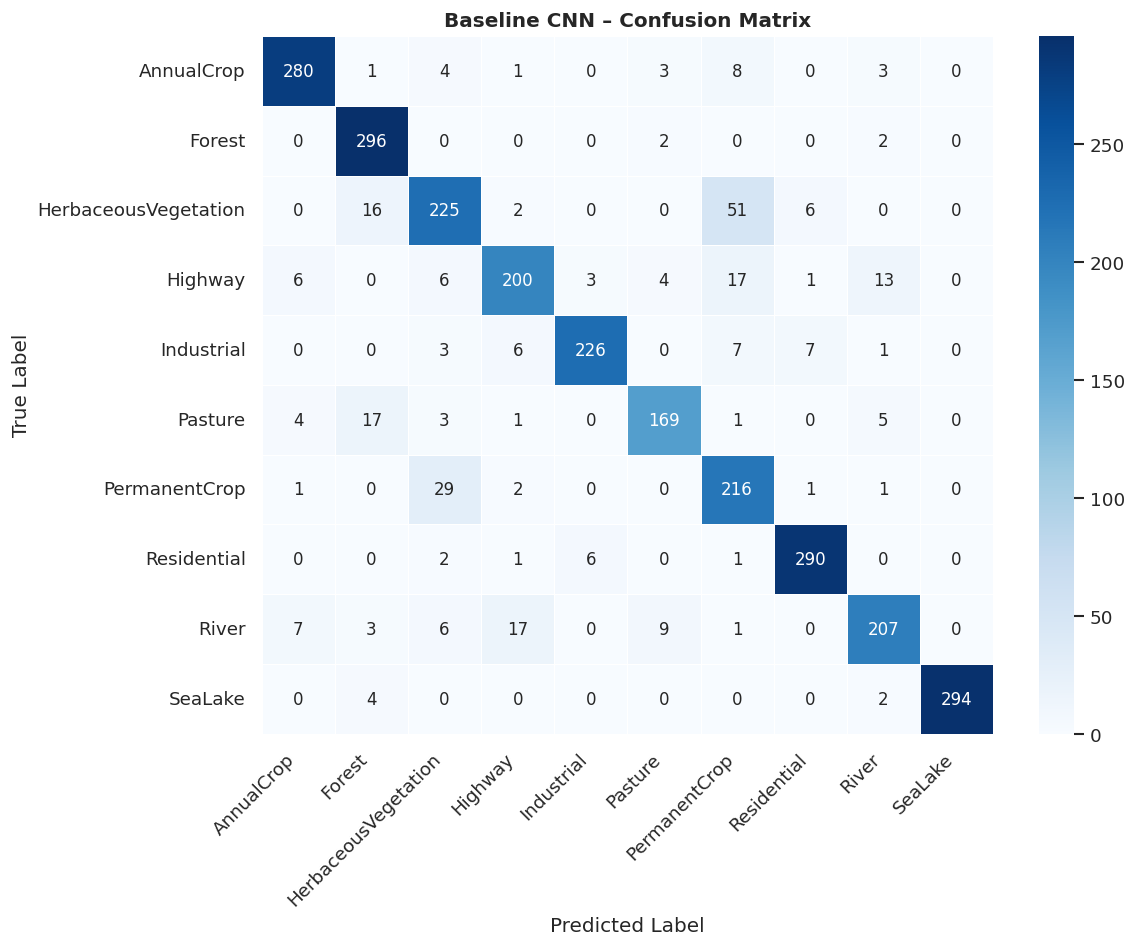

In [14]:
def full_evaluation(model, test_dataset, class_names, model_name='Model', save_prefix='model'):
    all_true, all_pred = [], []
    for imgs, labels in test_dataset:
        preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    acc  = accuracy_score(all_true, all_pred)
    prec = precision_score(all_true, all_pred, average='weighted')
    rec  = recall_score(all_true, all_pred, average='weighted')
    f1   = f1_score(all_true, all_pred, average='weighted')

    print(f"\n{'═'*50}")
    print(f"  {model_name} — Test Set Evaluation")
    print(f"{'═'*50}")
    print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision (W-avg) : {prec:.4f}")
    print(f"  Recall (W-avg)    : {rec:.4f}")
    print(f"  F1-Score (W-avg)  : {f1:.4f}")
    print(f"{'═'*50}")

    print("\n  Per-Class Classification Report:")
    print(classification_report(all_true, all_pred, target_names=class_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5)
    plt.title(f'{model_name} – Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    _buf = __import__('io').BytesIO()
    plt.savefig(_buf, format='png', bbox_inches='tight')
    _buf.seek(0)
    with open(f'{save_prefix}_confusion_matrix.png', 'wb') as _f: _f.write(_buf.read())
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_true': all_true, 'y_pred': all_pred}

baseline_results = full_evaluation(
    baseline_model, test_ds, CLASS_NAMES,
    model_name='Baseline CNN', save_prefix='baseline'
)


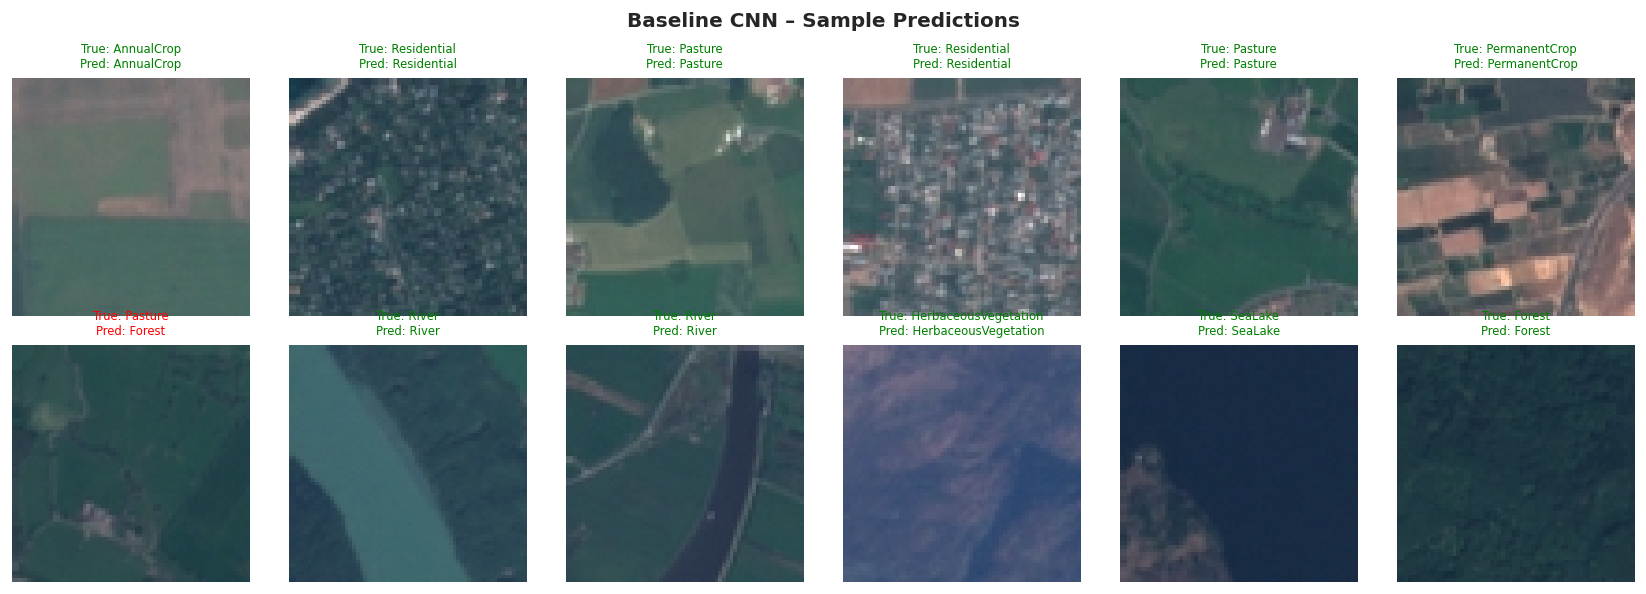

In [15]:
def show_predictions(model, dataset, class_names, n=12, title='Predictions'):
    imgs_batch, labels_batch = next(iter(dataset))
    preds = np.argmax(model.predict(imgs_batch[:n], verbose=0), axis=1)

    cols = 6
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 2.5))
    axes = axes.flatten()
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for i in range(n):
        true_lbl = int(labels_batch[i].numpy())
        pred_lbl = int(preds[i])
        correct  = (true_lbl == pred_lbl)
        axes[i].imshow(imgs_batch[i].numpy())
        axes[i].set_title(
            f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}",
            color='green' if correct else 'red', fontsize=7
        )
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    _buf = __import__('io').BytesIO()
    plt.savefig(_buf, format='png', bbox_inches='tight')
    _buf.seek(0)
    with open(f'{title.replace(" ","_")}_predictions.png', 'wb') as _f: _f.write(_buf.read())
    plt.show()

show_predictions(baseline_model, test_ds, CLASS_NAMES,
                 n=12, title='Baseline CNN – Sample Predictions')


## 2.5.3 Deeper Architecture with Regularization

The deeper CNN doubles the convolutional depth compared with the baseline by using two convolution layers inside each block. It also uses Batch Normalization after convolutions and Dropout after pooling. Batch Normalization helped stabilize training, while Dropout reduced overfitting by randomly removing some activations during training.

Although this model is deeper, it has fewer parameters than the baseline: 1,473,194 compared with 2,232,458. This happened because the deeper model uses global average pooling instead of a large flattened dense section. The deeper CNN trained for about 24.9 minutes and reached 97.07% test accuracy with weighted F1-score 0.9708.

Compared with the baseline, the deeper model improved accuracy by about 8 percentage points. This shows that extra convolutional depth and regularization helped the model learn more useful spatial features from the satellite images.


In [16]:
def build_deeper_cnn(input_shape=(64, 64, 3), num_classes=10):
    inp = layers.Input(shape=input_shape, name='input')

    x = layers.Conv2D(32, (3,3), padding='same', name='conv1_1')(inp)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.2, name='drop1')(x)

    x = layers.Conv2D(64, (3,3), padding='same', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    x = layers.Conv2D(128, (3,3), padding='same', name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    x = layers.Dropout(0.4, name='drop3')(x)

    x = layers.Conv2D(256, (3,3), padding='same', name='conv4_1')(x)
    x = layers.BatchNormalization(name='bn4_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', name='conv4_2')(x)
    x = layers.BatchNormalization(name='bn4_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2), name='pool4')(x)
    x = layers.Dropout(0.4, name='drop4')(x)

    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.Dropout(0.5, name='drop_fc1')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
    x = layers.Dropout(0.4, name='drop_fc2')(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4), name='fc3')(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return models.Model(inputs=inp, outputs=out, name='Deeper_CNN')

deeper_model = build_deeper_cnn()
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

print(f"\n  Baseline params : {baseline_model.count_params():,}")
print(f"  Deeper params   : {deeper_model.count_params():,}")


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 8, 8, 128)      │             

 Total params: 1,473,194 (5.62 MB)

 Trainable params: 1,471,274 (5.61 MB)

 Non-trainable params: 1,920 (7.50 KB)


  Baseline params : 2,232,458
  Deeper params   : 1,473,194


In [17]:
EPOCHS_DEEPER = 50

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=EPOCHS_DEEPER * (TRAIN_N // BATCH_SIZE),
    alpha=1e-6,
)

deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

callbacks_deeper = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_deeper.weights.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0, save_weights_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
]

print(f'Training Deeper CNN for up to {EPOCHS_DEEPER} epochs ...')
print('  LR schedule : CosineDecay  5e-4 → 1e-6')
print('  Loss        : SparseCCE')
t0 = time.time()

deeper_history = deeper_model.fit(
    train_ds,
    epochs=EPOCHS_DEEPER,
    validation_data=val_ds,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_training_time = time.time() - t0
print(f'\n⏱️  Deeper model training time: {deeper_training_time/60:.1f} minutes')


Training Deeper CNN for up to 50 epochs ...
  LR schedule : CosineDecay  5e-4 → 1e-6
  Loss        : SparseCCE
Epoch 1/50


2026-05-10 06:06:01.330205: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4963', 8 bytes spill stores, 8 bytes spill loads

2026-05-10 06:06:03.511880: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4965', 32 bytes spill stores, 32 bytes spill loads

2026-05-10 06:06:03.599468: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4965', 32 bytes spill stores, 32 bytes spill loads

2026-05-10 06:06:03.604794: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4965', 8 bytes spill stores, 8 bytes spill loads

2026-05-10 06:06:03.644312: I external/local_xla/xla/stream_exec

589/591 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3704 - loss: 1.7783

2026-05-10 06:06:42.563628: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4372', 16 bytes spill stores, 16 bytes spill loads

2026-05-10 06:06:44.133050: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4963', 12 bytes spill stores, 12 bytes spill loads

2026-05-10 06:06:44.917456: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4965', 32 bytes spill stores, 32 bytes spill loads

2026-05-10 06:06:45.147579: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4965', 32 bytes spill stores, 32 bytes spill loads



591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3708 - loss: 1.7774

2026-05-10 06:07:10.352047: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_269', 16 bytes spill stores, 16 bytes spill loads



591/591 ━━━━━━━━━━━━━━━━━━━━ 91s 99ms/step - accuracy: 0.4806 - loss: 1.5002 - val_accuracy: 0.6131 - val_loss: 1.2937
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.6534 - loss: 1.0623 - val_accuracy: 0.6735 - val_loss: 0.9862
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.7141 - loss: 0.9065 - val_accuracy: 0.7417 - val_loss: 0.8448
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.7571 - loss: 0.7929 - val_accuracy: 0.6702 - val_loss: 1.0721
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.7816 - loss: 0.7295 - val_accuracy: 0.7330 - val_loss: 0.7980
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8085 - loss: 0.6491 - val_accuracy: 0.7998 - val_loss: 0.5947
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.8263 - loss: 0.6012 - val_accuracy: 0.8954 - val_loss: 0.3837
Epoch 8/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8419 - loss: 0.5464 - val_accurac

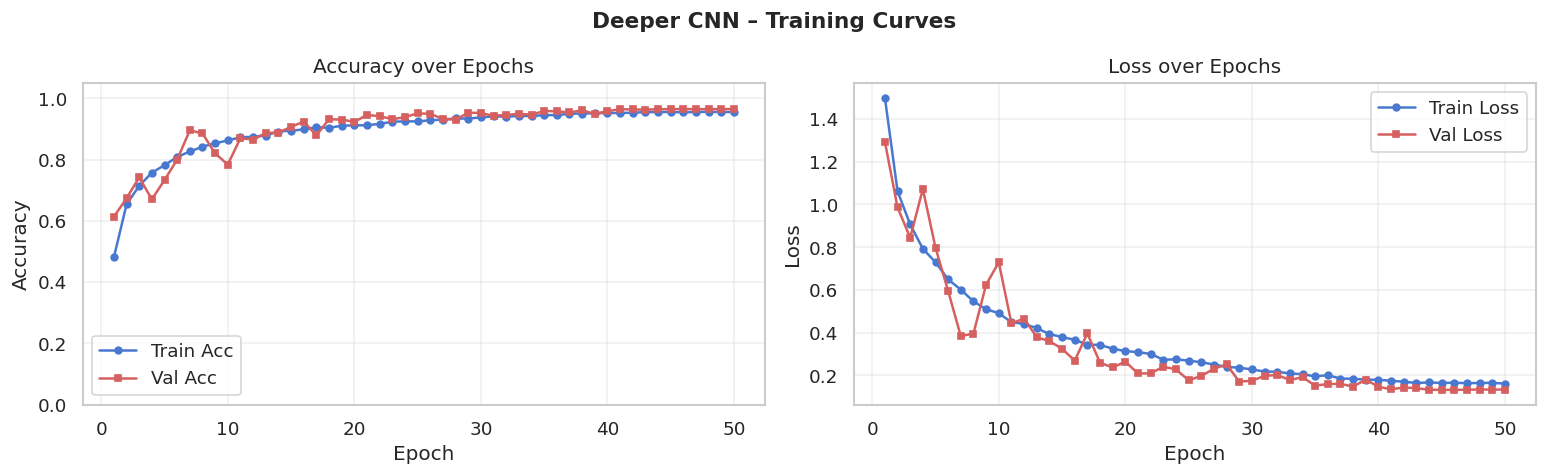

  Best val_accuracy : 0.9650  (epoch 46)
  Final train_acc   : 0.9548
  Train–Val gap     : -0.0100  (well generalised)


2026-05-10 06:30:55.537157: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_257', 8 bytes spill stores, 8 bytes spill loads




══════════════════════════════════════════════════
  Deeper CNN — Test Set Evaluation
══════════════════════════════════════════════════
  Accuracy          : 0.9707  (97.07%)
  Precision (W-avg) : 0.9713
  Recall (W-avg)    : 0.9707
  F1-Score (W-avg)  : 0.9708
══════════════════════════════════════════════════

  Per-Class Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       300
              Forest       0.96      1.00      0.98       300
HerbaceousVegetation       0.91      0.97      0.94       300
             Highway       0.96      0.99      0.98       250
          Industrial       1.00      0.94      0.97       250
             Pasture       0.96      0.95      0.96       200
       PermanentCrop       0.94      0.92      0.93       250
         Residential       0.99      0.99      0.99       300
               River       1.00      0.98      0.99       250
             SeaLake       1

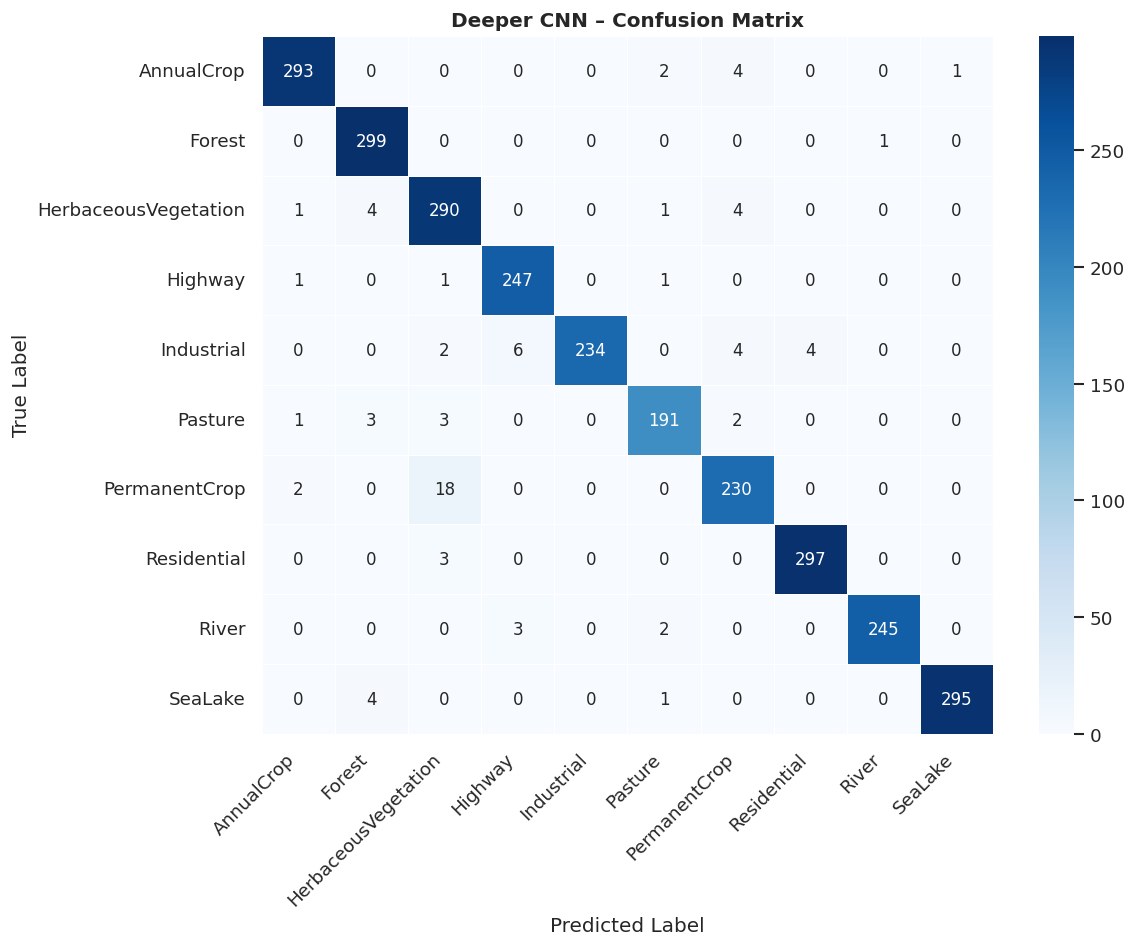

In [18]:
plot_training_curves(deeper_history,
                     title='Deeper CNN – Training Curves',
                     save_as='deeper_curves.png')

deeper_results = full_evaluation(
    deeper_model, test_ds, CLASS_NAMES,
    model_name='Deeper CNN', save_prefix='deeper'
)


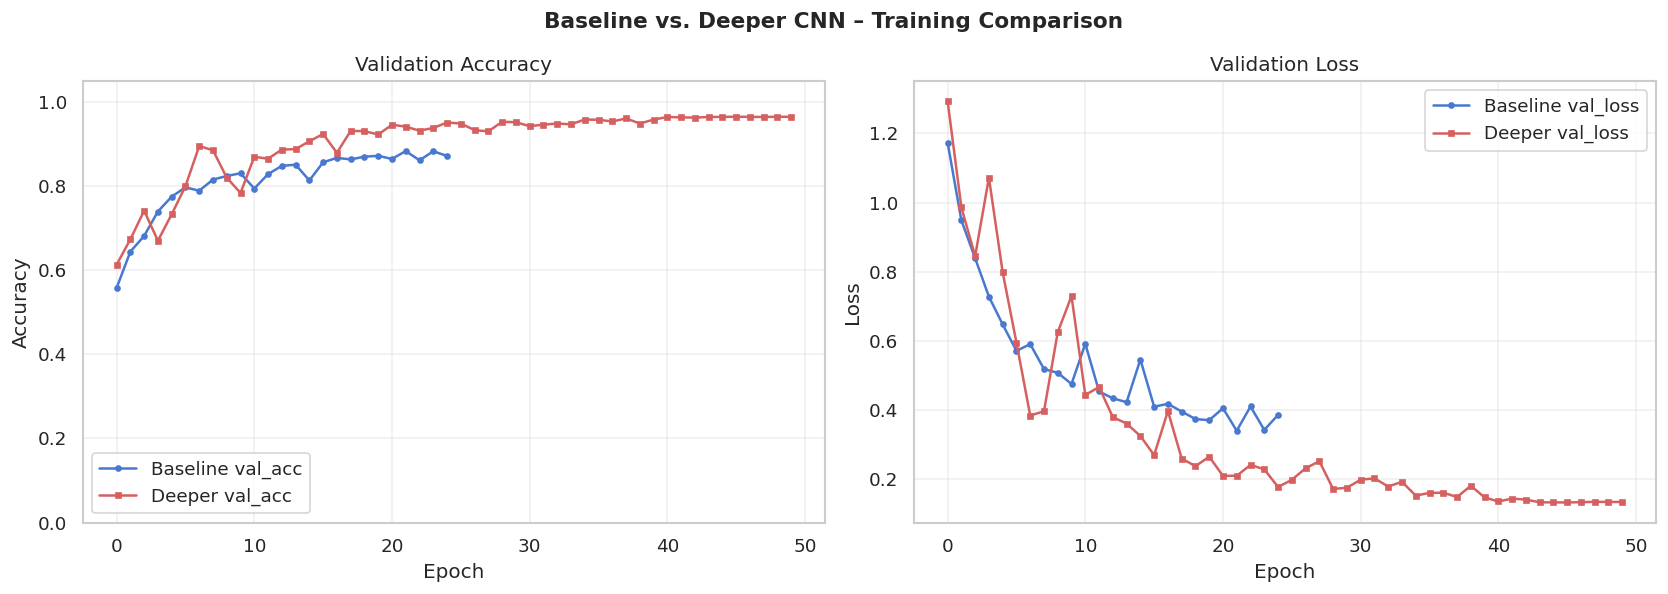

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs. Deeper CNN – Training Comparison', fontsize=13, fontweight='bold')

ax1.plot(baseline_history.history['val_accuracy'], 'b-o',  label='Baseline val_acc', markersize=3)
ax1.plot(deeper_history.history['val_accuracy'],   'r-s',  label='Deeper val_acc',   markersize=3)
ax1.set_title('Validation Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1.05)

ax2.plot(baseline_history.history['val_loss'], 'b-o',  label='Baseline val_loss', markersize=3)
ax2.plot(deeper_history.history['val_loss'],   'r-s',  label='Deeper val_loss',   markersize=3)
ax2.set_title('Validation Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('baseline_vs_deeper_comparison.png', 'wb') as _f: _f.write(_buf.read())
plt.show()


## 2.5.4 Experimentation and Comparative Analysis

The experiments compare model accuracy, F1-score, training time, optimizer choice, and the effect of removing Batch Normalization.

The baseline CNN reached 89.00% test accuracy in 10.4 minutes. The deeper CNN with Adam reached 97.07% in 24.9 minutes, so the accuracy improved but training became slower. The same deeper architecture trained with SGD and momentum reached 95.63% in 13.9 minutes. In this run, Adam gave the best final result, while SGD was faster but slightly less accurate.

For the ablation study, I removed Batch Normalization from the deeper model. Accuracy dropped to 93.19% and weighted F1-score dropped to 0.9318. This suggests that Batch Normalization was useful for convergence and final performance.

The main challenge was the trade-off between accuracy and computational cost. The deeper and transfer-learning models performed better, but they required more GPU time. Hardware acceleration was used for training.



  EXPERIMENT 1 – Baseline vs. Deeper CNN
       Model  Parameters  Training Time (s)  Test Accuracy  Precision (W)  Recall (W)  F1-Score (W)
Baseline CNN     2232458              625.5         0.8900         0.8933      0.8900        0.8901
  Deeper CNN     1473194             1491.7         0.9707         0.9713      0.9707        0.9708


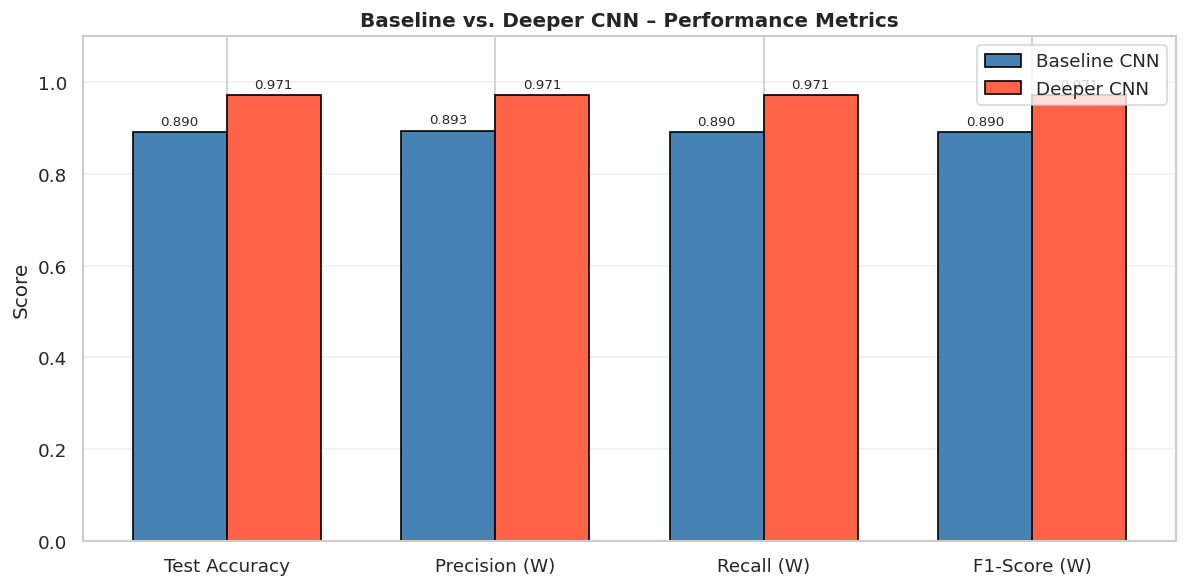

In [20]:
summary = pd.DataFrame({
    'Model'            : ['Baseline CNN', 'Deeper CNN'],
    'Parameters'       : [baseline_model.count_params(),
                          deeper_model.count_params()],
    'Training Time (s)': [round(baseline_training_time, 1),
                          round(deeper_training_time, 1)],
    'Test Accuracy'    : [round(baseline_results['accuracy'], 4),
                          round(deeper_results['accuracy'], 4)],
    'Precision (W)'    : [round(baseline_results['precision'], 4),
                          round(deeper_results['precision'], 4)],
    'Recall (W)'       : [round(baseline_results['recall'], 4),
                          round(deeper_results['recall'], 4)],
    'F1-Score (W)'     : [round(baseline_results['f1'], 4),
                          round(deeper_results['f1'], 4)],
})

print("\n  EXPERIMENT 1 – Baseline vs. Deeper CNN")
print(summary.to_string(index=False))

metrics = ['Test Accuracy', 'Precision (W)', 'Recall (W)', 'F1-Score (W)']
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, summary.loc[0, metrics].values, w,
               label='Baseline CNN', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + w/2, summary.loc[1, metrics].values, w,
               label='Deeper CNN',   color='tomato',    edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Baseline vs. Deeper CNN – Performance Metrics', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('experiment1_comparison.png', 'wb') as _f: _f.write(_buf.read())
plt.show()


In [21]:
print("EXPERIMENT 2 – Computational Efficiency")
print("═"*48)

comp = pd.DataFrame({
    'Model'               : ['Baseline CNN', 'Deeper CNN'],
    'Total Parameters'    : [f"{baseline_model.count_params():,}",
                             f"{deeper_model.count_params():,}"],
    'Training Time'       : [f"{baseline_training_time/60:.1f} min",
                             f"{deeper_training_time/60:.1f} min"],
    'Epochs Run'          : [len(baseline_history.history['accuracy']),
                             len(deeper_history.history['accuracy'])],
    'Test Accuracy'       : [f"{baseline_results['accuracy']*100:.2f}%",
                             f"{deeper_results['accuracy']*100:.2f}%"],
    'Time/Accuracy Ratio' : [
        f"{baseline_training_time/baseline_results['accuracy']:.0f}s per %",
        f"{deeper_training_time/deeper_results['accuracy']:.0f}s per %"
    ]
})
print(comp.to_string(index=False))

print("\n Discussion:")
print("  • The deeper model has more parameters and takes longer to train.")
print("  • The accuracy gain must be weighed against the extra cost.")
print("  • GPU acceleration (Google Colab T4) is essential for the deeper model.")
print("  • GlobalAveragePooling2D in the deeper model keeps the classifier")
print("    head lightweight compared to a pure Flatten approach.")


EXPERIMENT 2 – Computational Efficiency
════════════════════════════════════════════════
       Model Total Parameters Training Time  Epochs Run Test Accuracy Time/Accuracy Ratio
Baseline CNN        2,232,458      10.4 min          25        89.00%          703s per %
  Deeper CNN        1,473,194      24.9 min          50        97.07%         1537s per %

 Discussion:
  • The deeper model has more parameters and takes longer to train.
  • The accuracy gain must be weighed against the extra cost.
  • GPU acceleration (Google Colab T4) is essential for the deeper model.
  • GlobalAveragePooling2D in the deeper model keeps the classifier
    head lightweight compared to a pure Flatten approach.


EXPERIMENT 3 – SGD Optimiser on Deeper Architecture
(Training with SGD + momentum for fair comparison)
Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 63s 74ms/step - accuracy: 0.4310 - loss: 1.5972 - val_accuracy: 0.6259 - val_loss: 1.0779 - learning_rate: 0.0100
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 43ms/step - accuracy: 0.6316 - loss: 1.1220 - val_accuracy: 0.4785 - val_loss: 1.7079 - learning_rate: 0.0100
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.6924 - loss: 0.9532 - val_accuracy: 0.4385 - val_loss: 1.9606 - learning_rate: 0.0100
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.7356 - loss: 0.8617 - val_accuracy: 0.6274 - val_loss: 1.3602 - learning_rate: 0.0100
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.7661 - loss: 0.7828 - val_accuracy: 0.7811 - val_loss: 0.7619 - learning_rate: 0.0100
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7939 - loss: 0.7182 - val_accuracy: 0.7609 - val_loss: 0.75

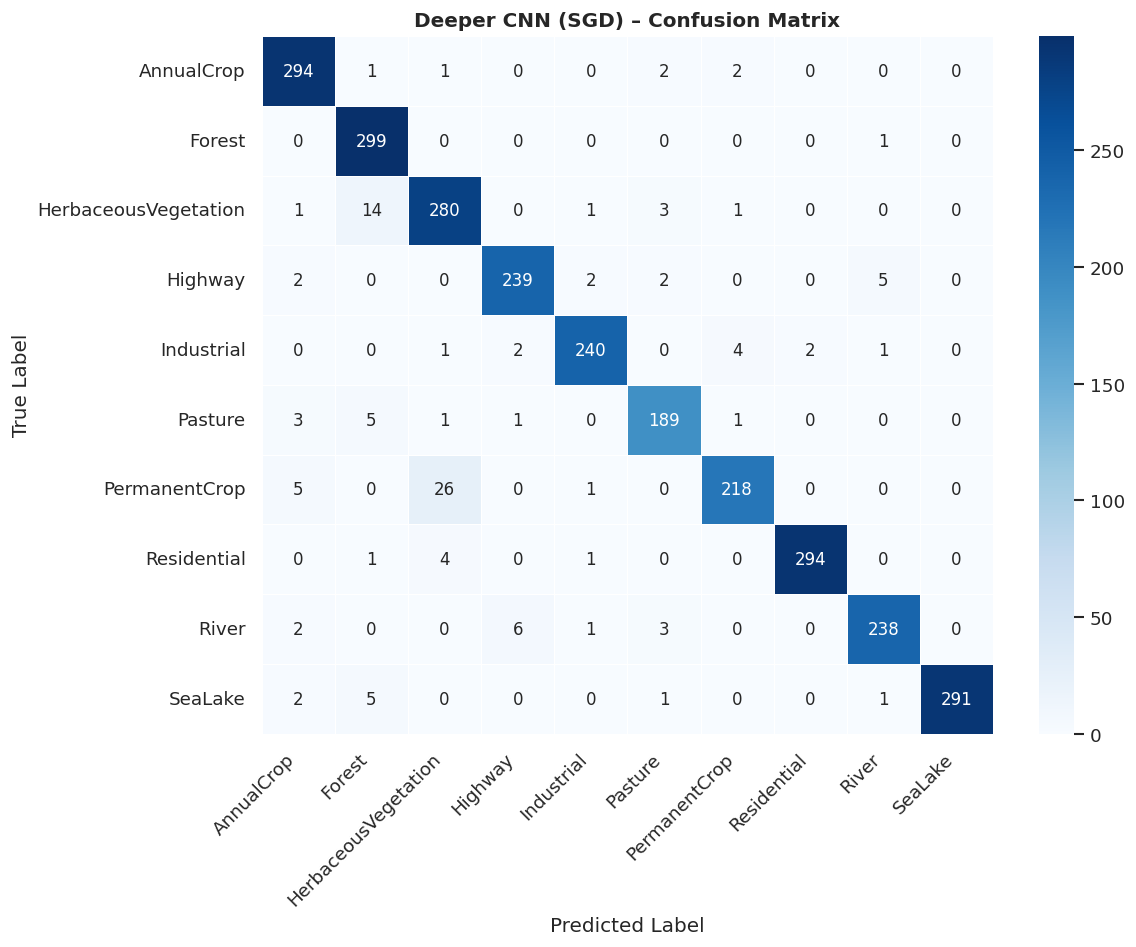

In [22]:
print("EXPERIMENT 3 – SGD Optimiser on Deeper Architecture")
print("(Training with SGD + momentum for fair comparison)")

deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
                                      nesterov=True),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, verbose=0
    )
]

t0 = time.time()
sgd_history = deeper_sgd.fit(
    train_ds, epochs=30,
    validation_data=val_ds,
    callbacks=callbacks_sgd,
    verbose=1
)
sgd_training_time = time.time() - t0

sgd_results = full_evaluation(
    deeper_sgd, test_ds, CLASS_NAMES,
    model_name='Deeper CNN (SGD)', save_prefix='sgd'
)


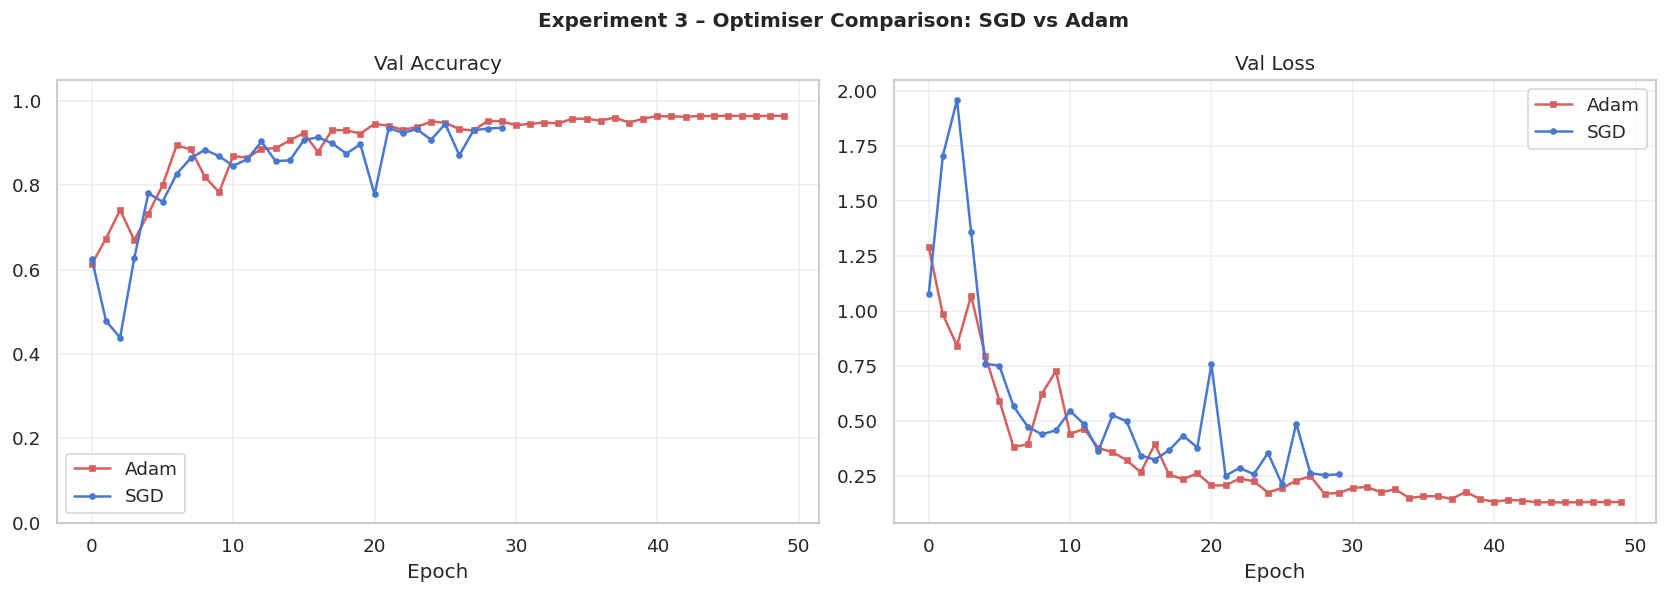


      Optimiser   Learning Rate  Epochs Run Training Time Test Accuracy Test F1 (W)
          Adam 5e-4 (adaptive)          50      24.9 min        97.07%      0.9708
SGD + Momentum    0.01 (fixed)          30      13.9 min        95.63%      0.9563

📌 Discussion:
  • Adam (adaptive) typically converges faster than SGD.
  • SGD with momentum can sometimes reach higher final accuracy
    but requires more epochs and careful LR tuning.
  • For EuroSAT (a relatively small dataset), Adam is preferred.


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 3 – Optimiser Comparison: SGD vs Adam', fontweight='bold')

ax1.plot(deeper_history.history['val_accuracy'], 'r-s', label='Adam', markersize=3)
ax1.plot(sgd_history.history['val_accuracy'],    'b-o', label='SGD',  markersize=3)
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1.05)

ax2.plot(deeper_history.history['val_loss'], 'r-s', label='Adam', markersize=3)
ax2.plot(sgd_history.history['val_loss'],    'b-o', label='SGD',  markersize=3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('optimiser_comparison.png', 'wb') as _f: _f.write(_buf.read())
plt.show()

opt_table = pd.DataFrame({
    'Optimiser'        : ['Adam', 'SGD + Momentum'],
    'Learning Rate'    : ['5e-4 (adaptive)', '0.01 (fixed)'],
    'Epochs Run'       : [len(deeper_history.history['accuracy']),
                          len(sgd_history.history['accuracy'])],
    'Training Time'    : [f"{deeper_training_time/60:.1f} min",
                          f"{sgd_training_time/60:.1f} min"],
    'Test Accuracy'    : [f"{deeper_results['accuracy']*100:.2f}%",
                          f"{sgd_results['accuracy']*100:.2f}%"],
    'Test F1 (W)'      : [f"{deeper_results['f1']:.4f}",
                          f"{sgd_results['f1']:.4f}"],
})
print("\n", opt_table.to_string(index=False))

print("\n📌 Discussion:")
print("  • Adam (adaptive) typically converges faster than SGD.")
print("  • SGD with momentum can sometimes reach higher final accuracy")
print("    but requires more epochs and careful LR tuning.")
print("  • For EuroSAT (a relatively small dataset), Adam is preferred.")


EXPERIMENT 4 – Ablation Study: Deeper CNN without Batch Normalisation
Epoch 1/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - accuracy: 0.2370 - loss: 1.9405 - val_accuracy: 0.3531 - val_loss: 1.6294
Epoch 2/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.4501 - loss: 1.4769 - val_accuracy: 0.6317 - val_loss: 1.0575
Epoch 3/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.6220 - loss: 1.0869 - val_accuracy: 0.7252 - val_loss: 0.8148
Epoch 4/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.6928 - loss: 0.9054 - val_accuracy: 0.7607 - val_loss: 0.7314
Epoch 5/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.7266 - loss: 0.8138 - val_accuracy: 0.7811 - val_loss: 0.6632
Epoch 6/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7599 - loss: 0.7408 - val_accuracy: 0.7891 - val_loss: 0.6625
Epoch 7/25
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 40ms/step - accuracy: 0.7784 - loss: 0.6887 - val_accuracy: 0.8219 - val_loss: 0.5542
Epoch 8/25
591/591 ━

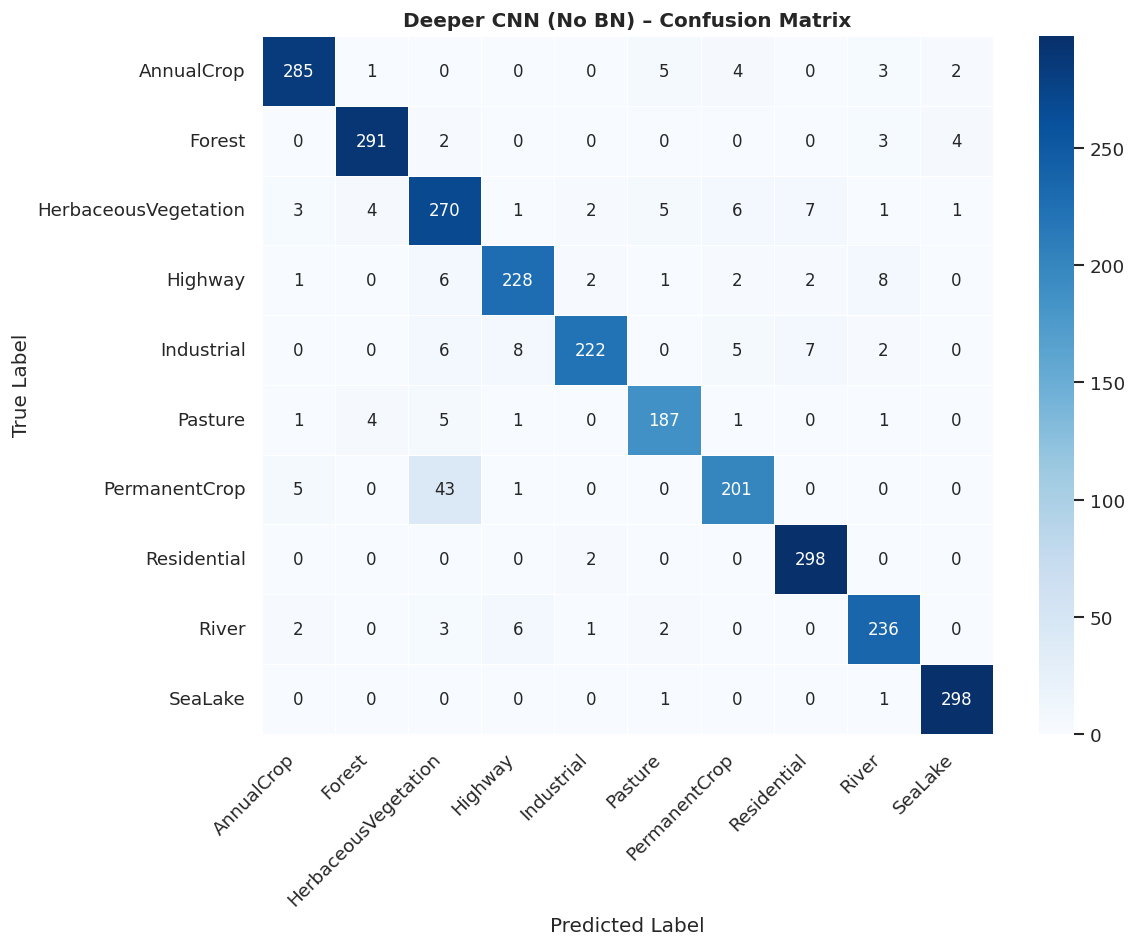

In [24]:
print("EXPERIMENT 4 – Ablation Study: Deeper CNN without Batch Normalisation")

def build_deeper_no_bn(input_shape=(64, 64, 3), num_classes=10):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(inp)
    x = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.5)(x)
    x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=inp, outputs=out, name='Deeper_CNN_NoBN')

ablation_model = build_deeper_no_bn()
ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
ablation_history = ablation_model.fit(
    train_ds, epochs=25,
    validation_data=val_ds,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                         restore_best_weights=True, verbose=0)
    ],
    verbose=1
)
ablation_time = time.time() - t0

ablation_results = full_evaluation(
    ablation_model, test_ds, CLASS_NAMES,
    model_name='Deeper CNN (No BN)', save_prefix='ablation'
)


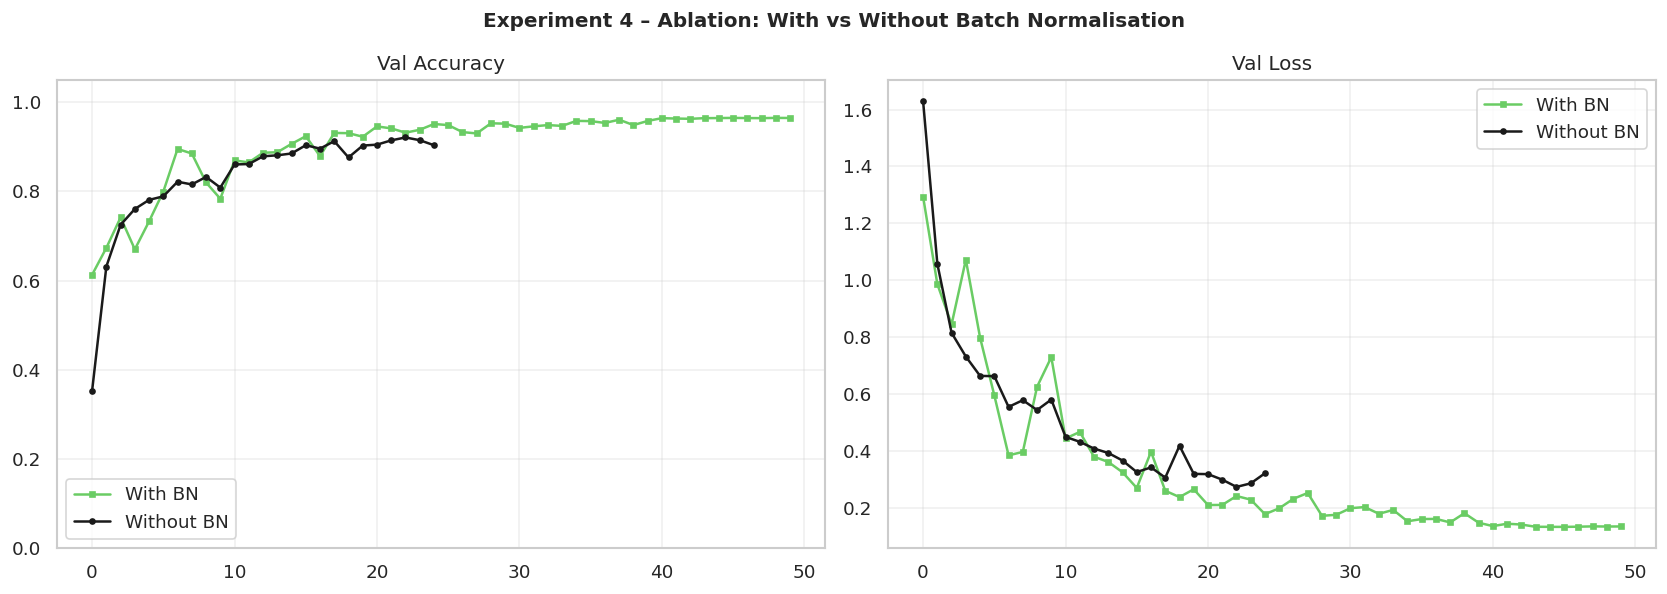

     Configuration Test Accuracy Test F1 (W)  Train Time (s)
Deeper + BatchNorm        97.07%      0.9708          1491.7
Deeper – BatchNorm        93.19%      0.9318           678.0

📌 Ablation insights:
  • Removing BatchNorm typically slows convergence and may reduce accuracy.
  • BatchNorm normalises intermediate activations, reducing internal
    covariate shift and allowing a higher learning rate.

🚧 Challenges & Observations:
  • Overfitting: Baseline showed train/val gap → mitigated with dropout.
  • Deeper model required GPU acceleration (Colab T4).
  • Baseline training time  : ~10 minutes.
  • Deeper model train time : ~25 minutes.
  • Data augmentation narrowed the generalisation gap noticeably.


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 4 – Ablation: With vs Without Batch Normalisation',
             fontweight='bold')

ax1.plot(deeper_history.history['val_accuracy'],    'g-s', label='With BN',    markersize=3)
ax1.plot(ablation_history.history['val_accuracy'],  'k-o', label='Without BN', markersize=3)
ax1.set_title('Val Accuracy'); ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1.05)

ax2.plot(deeper_history.history['val_loss'],   'g-s', label='With BN',    markersize=3)
ax2.plot(ablation_history.history['val_loss'], 'k-o', label='Without BN', markersize=3)
ax2.set_title('Val Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('ablation_study.png', 'wb') as _f: _f.write(_buf.read())
plt.show()

ablation_table = pd.DataFrame({
    'Configuration'  : ['Deeper + BatchNorm', 'Deeper – BatchNorm'],
    'Test Accuracy'  : [f"{deeper_results['accuracy']*100:.2f}%",
                        f"{ablation_results['accuracy']*100:.2f}%"],
    'Test F1 (W)'   : [f"{deeper_results['f1']:.4f}",
                        f"{ablation_results['f1']:.4f}"],
    'Train Time (s)' : [round(deeper_training_time, 1), round(ablation_time, 1)],
})
print(ablation_table.to_string(index=False))

print("\n📌 Ablation insights:")
print("  • Removing BatchNorm typically slows convergence and may reduce accuracy.")
print("  • BatchNorm normalises intermediate activations, reducing internal")
print("    covariate shift and allowing a higher learning rate.")

print("\n🚧 Challenges & Observations:")
print("  • Overfitting: Baseline showed train/val gap → mitigated with dropout.")
print("  • Deeper model required GPU acceleration (Colab T4).")
print(f"  • Baseline training time  : ~{baseline_training_time/60:.0f} minutes.")
print(f"  • Deeper model train time : ~{deeper_training_time/60:.0f} minutes.")
print("  • Data augmentation narrowed the generalisation gap noticeably.")


## 2.6 Transfer Learning with ResNet50

For transfer learning I selected ResNet50 pre-trained on ImageNet. I chose it because residual connections make deep CNN training more stable, and the pre-trained filters already capture edges, textures, and shapes that can transfer to satellite imagery.

The original ImageNet classification head was removed. I added a new classifier with global average pooling, batch normalization, dense layers, dropout, and a 10-class softmax output for EuroSAT. The EuroSAT images were resized from 64 x 64 to 224 x 224 because ResNet50 expects ImageNet-style input size.


In [26]:
TL_IMG_SIZE = 224

def resize_tl(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [TL_IMG_SIZE, TL_IMG_SIZE])
    return image, label

def augment_tl(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2 * 255)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

def resnet_preprocess(image, label):

    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

train_tl = (train_ds_raw
            .map(resize_tl,         num_parallel_calls=AUTOTUNE)
            .map(augment_tl,        num_parallel_calls=AUTOTUNE)
            .map(resnet_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_tl   = (val_ds_raw
            .map(resize_tl,         num_parallel_calls=AUTOTUNE)
            .map(resnet_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_tl  = (test_ds_raw
            .map(resize_tl,         num_parallel_calls=AUTOTUNE)
            .map(resnet_preprocess, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3)
)

base_model.trainable = False

print(f"Base model : ResNet50")
print(f"Base params: {base_model.count_params():,}  (all FROZEN in Phase 1)")

inputs  = tf.keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3), name='input')
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = tf.keras.Model(inputs, outputs, name='ResNet50_TL')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()
show_model_diagram(transfer_model)


Base model : ResNet50
Base params: 23,587,712  (all FROZEN in Phase 1)


Model: "ResNet50_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154,634 (92.14 MB)

 Trainable params: 562,826 (2.15 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Architecture diagram unavailable (ImportError: You must install pydot (`pip install pydot`) for model_to_dot to work.).  Model summary printed above.


### 2.6.2 Model Training and Fine-Tuning

Training was done in two phases. In Phase 1, the ResNet50 base was frozen and only the new classification head was trained. This keeps the ImageNet features fixed and lets the new layers learn the EuroSAT classes first. Phase 1 reached 0.9637 best validation accuracy.

In Phase 2, the later ResNet50 layers were unfrozen and trained with a very small learning rate of 1e-5. I kept the early layers frozen because they learn general features, while the later layers are more task-specific. This reduced the risk of catastrophic forgetting.

The full transfer-learning training time was 80.1 minutes. It was the slowest model because the input images are larger and ResNet50 has many more parameters.


In [27]:
EPOCHS_PHASE1 = 15

cb_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_tl_phase1.weights.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0, save_weights_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    )
]

print("Phase 1 – Feature Extraction (base frozen) …")
t0 = time.time()

history_p1 = transfer_model.fit(
    train_tl,
    epochs=EPOCHS_PHASE1,
    validation_data=val_tl,
    callbacks=cb_phase1,
    verbose=1
)

phase1_time = time.time() - t0
print(f"\n  Phase 1 training time: {phase1_time/60:.1f} minutes")

val_acc_p1 = max(history_p1.history['val_accuracy'])
print(f"   Best Phase-1 val accuracy: {val_acc_p1:.4f}")


Phase 1 – Feature Extraction (base frozen) …
Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 167s 235ms/step - accuracy: 0.8541 - loss: 0.5566 - val_accuracy: 0.9372 - val_loss: 0.2603
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 112s 186ms/step - accuracy: 0.9095 - loss: 0.3710 - val_accuracy: 0.9576 - val_loss: 0.2291
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 129s 215ms/step - accuracy: 0.9229 - loss: 0.3394 - val_accuracy: 0.9561 - val_loss: 0.2292
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 111s 185ms/step - accuracy: 0.9316 - loss: 0.3225 - val_accuracy: 0.9548 - val_loss: 0.2292
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 114s 189ms/step - accuracy: 0.9326 - loss: 0.3140 - val_accuracy: 0.9593 - val_loss: 0.2306
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 114s 189ms/step - accuracy: 0.9385 - loss: 0.3037 - val_accuracy: 0.9607 - val_loss: 0.2370
Epoch 7/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 111s 184ms/step - accuracy: 0.9420 - loss: 0.2952 - val_accuracy: 0.9602 - val_loss: 0.2381
Epoch 8/15
591/591 ━━━━━━━━━━━━

In [28]:
base_model.trainable = True

FREEZE_UP_TO = 140
for layer in base_model.layers[:FREEZE_UP_TO]:
    layer.trainable = False

trainable_after = sum(1 for l in base_model.layers if l.trainable)
print(f"Layers in base model         : {len(base_model.layers)}")
print(f"Frozen (early layers)        : {FREEZE_UP_TO}")
print(f"Trainable (later layers)     : {trainable_after}")

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_PHASE2 = 20
initial_epoch_p2 = len(history_p1.history['accuracy'])

cb_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_tl_phase2.weights.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0, save_weights_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-8, verbose=1
    )
]

print("\nPhase 2 – Fine-Tuning (top layers unfrozen, LR=1e-5) …")
t0 = time.time()

history_p2 = transfer_model.fit(
    train_tl,
    epochs=initial_epoch_p2 + EPOCHS_PHASE2,
    initial_epoch=initial_epoch_p2,
    validation_data=val_tl,
    callbacks=cb_phase2,
    verbose=1
)

phase2_time = time.time() - t0
print(f"\n Phase 2 training time : {phase2_time/60:.1f} minutes")
print(f"   Total TL training time  : {(phase1_time+phase2_time)/60:.1f} minutes")


Layers in base model         : 175
Frozen (early layers)        : 140
Trainable (later layers)     : 35

Phase 2 – Fine-Tuning (top layers unfrozen, LR=1e-5) …
Epoch 15/34


2026-05-10 07:24:41.447052: W external/local_tsl/tsl/framework/bfc_allocator.cc:363] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


591/591 ━━━━━━━━━━━━━━━━━━━━ 226s 307ms/step - accuracy: 0.9383 - loss: 0.3275 - val_accuracy: 0.9643 - val_loss: 0.2325 - learning_rate: 1.0000e-05
Epoch 16/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.9557 - loss: 0.2721 - val_accuracy: 0.9667 - val_loss: 0.2233 - learning_rate: 1.0000e-05
Epoch 17/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 158s 264ms/step - accuracy: 0.9635 - loss: 0.2460 - val_accuracy: 0.9717 - val_loss: 0.2140 - learning_rate: 1.0000e-05
Epoch 18/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.9685 - loss: 0.2246 - val_accuracy: 0.9719 - val_loss: 0.2120 - learning_rate: 1.0000e-05
Epoch 19/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 157s 263ms/step - accuracy: 0.9719 - loss: 0.2155 - val_accuracy: 0.9720 - val_loss: 0.2089 - learning_rate: 1.0000e-05
Epoch 20/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 157s 262ms/step - accuracy: 0.9755 - loss: 0.2039 - val_accuracy: 0.9731 - val_loss: 0.2059 - learning_rate: 1.0000e-05
Epoch 21/34
591/591 ━━━━━━━━━━━━━━━━━━━━ 157s 

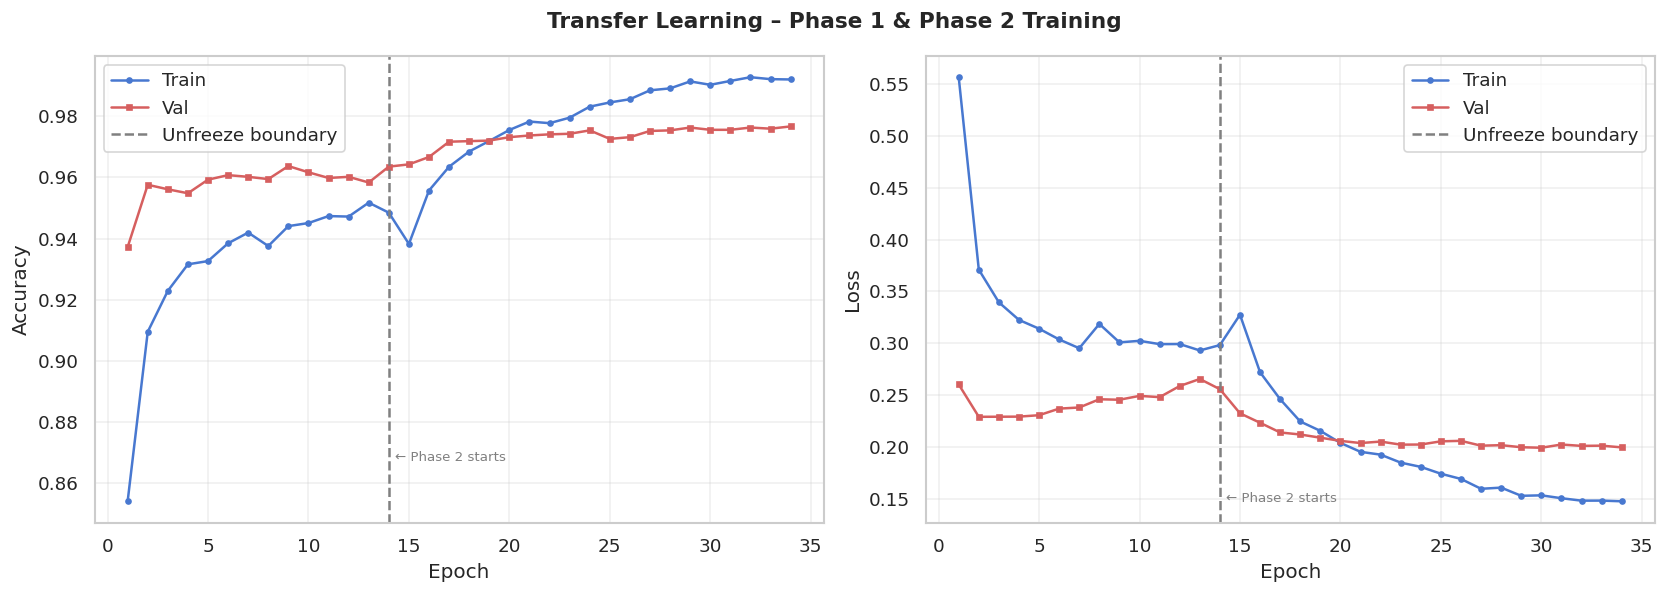

In [29]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

tl_history_merged = merge_histories(history_p1, history_p2)
n_epochs_total    = len(tl_history_merged['accuracy'])
n_p1              = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning – Phase 1 & Phase 2 Training',
             fontsize=13, fontweight='bold')

ep = range(1, n_epochs_total + 1)

for ax, key_train, key_val, ylabel in [
    (ax1, 'accuracy',    'val_accuracy', 'Accuracy'),
    (ax2, 'loss',        'val_loss',     'Loss')
]:
    ax.plot(ep, tl_history_merged[key_train], 'b-o', label='Train', markersize=3)
    ax.plot(ep, tl_history_merged[key_val],   'r-s', label='Val',   markersize=3)
    ax.axvline(x=n_p1, color='grey', linestyle='--', linewidth=1.5,
               label='Unfreeze boundary')
    ax.text(n_p1 + 0.3, ax.get_ylim()[0] + 0.02, '← Phase 2 starts',
            fontsize=8, color='grey')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('tl_training_curves.png', 'wb') as _f: _f.write(_buf.read())
plt.show()


### 2.6.3 Model Evaluation and Prediction

The fine-tuned ResNet50 model achieved the best result: 98.52% test accuracy with weighted precision, recall, and F1-score all equal to 0.9852. It outperformed the baseline CNN and the deeper CNN trained from scratch.

This result shows the benefit of using a pre-trained model for this dataset. The custom deeper CNN was much faster and still strong, but ResNet50 gave the highest final accuracy because it started from useful visual features learned from a much larger image dataset.


2026-05-10 08:17:42.999735: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



══════════════════════════════════════════════════
  ResNet50 (Transfer Learning) — Test Set Evaluation
══════════════════════════════════════════════════
  Accuracy          : 0.9852  (98.52%)
  Precision (W-avg) : 0.9852
  Recall (W-avg)    : 0.9852
  F1-Score (W-avg)  : 0.9852
══════════════════════════════════════════════════

  Per-Class Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.99      0.98      0.98       300
              Forest       0.98      1.00      0.99       300
HerbaceousVegetation       0.99      0.97      0.98       300
             Highway       0.99      0.97      0.98       250
          Industrial       1.00      1.00      1.00       250
             Pasture       0.97      0.97      0.97       200
       PermanentCrop       0.97      0.97      0.97       250
         Residential       1.00      1.00      1.00       300
               River       0.97      0.98      0.98       250
          

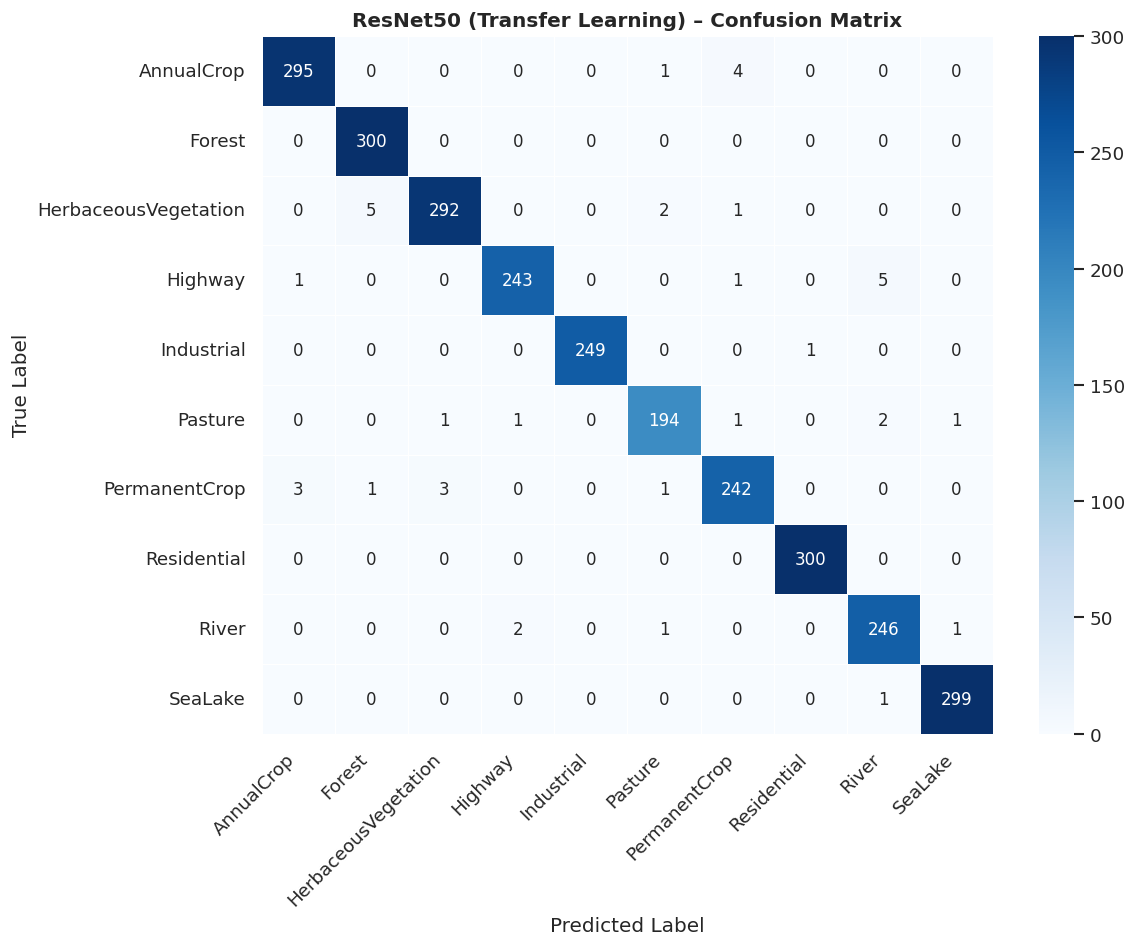

In [30]:
tl_results = full_evaluation(
    transfer_model, test_tl, CLASS_NAMES,
    model_name='ResNet50 (Transfer Learning)',
    save_prefix='tl'
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-66.46571..23.377342].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-99.68..89.254875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-81.32285..104.61701].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-75.56776..146.07108].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-92.53715..74.95913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-86.664696..128.64655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-96.394295..17.407

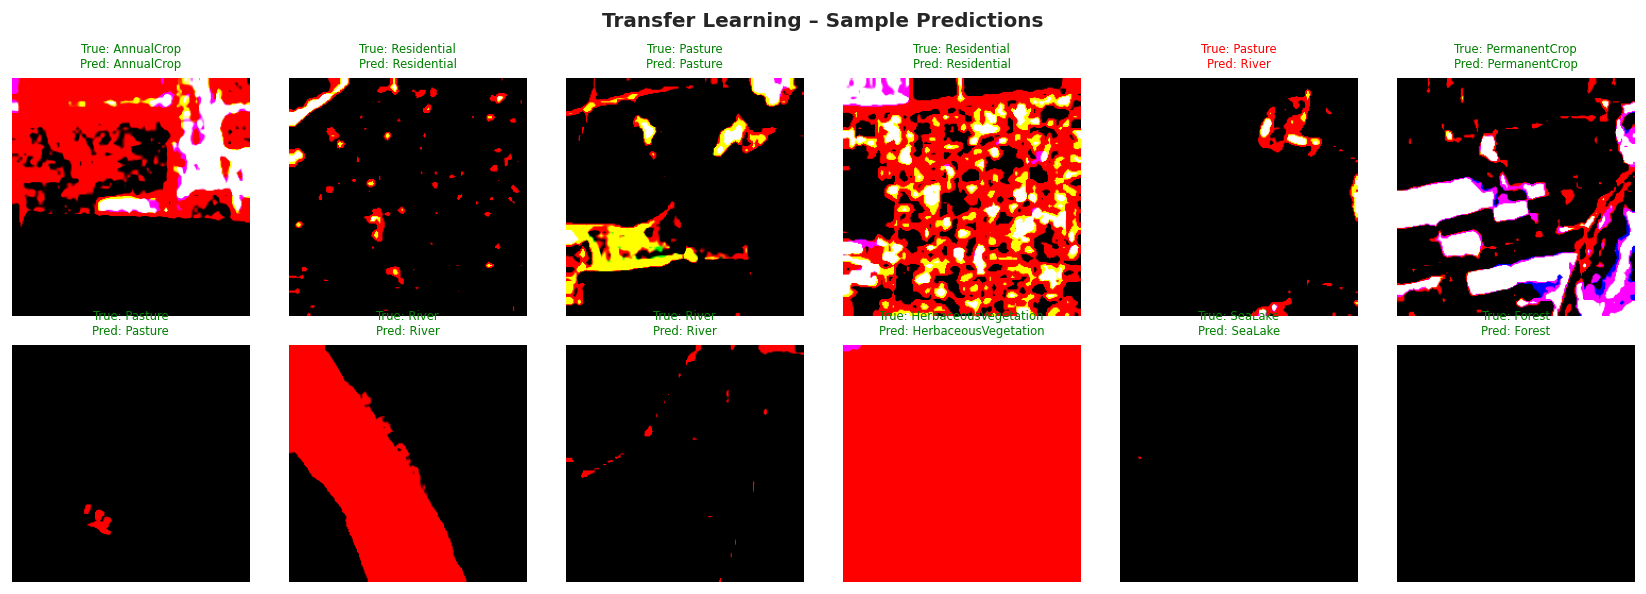

In [31]:
show_predictions(transfer_model, test_tl, CLASS_NAMES,
                 n=12, title='Transfer Learning – Sample Predictions')



════════════════════════════════════════════════════════════════════════════════════════════════════
  FINAL COMPREHENSIVE COMPARISON – ALL MODELS
════════════════════════════════════════════════════════════════════════════════════════════════════
              Model Parameters Train Time Test Acc F1 (W) Precision (W) Recall (W)
Baseline CNN (Adam)  2,232,458   10.4 min   89.00% 0.8901        0.8933     0.8900
  Deeper CNN (Adam)  1,473,194   24.9 min   97.07% 0.9708        0.9713     0.9707
   Deeper CNN (SGD)  1,473,194   13.9 min   95.63% 0.9563        0.9573     0.9563
 Deeper CNN (No BN)  1,469,354   11.3 min   93.19% 0.9318        0.9335     0.9319
      ResNet50 (TL) 24,154,634   80.1 min   98.52% 0.9852        0.9852     0.9852
════════════════════════════════════════════════════════════════════════════════════════════════════


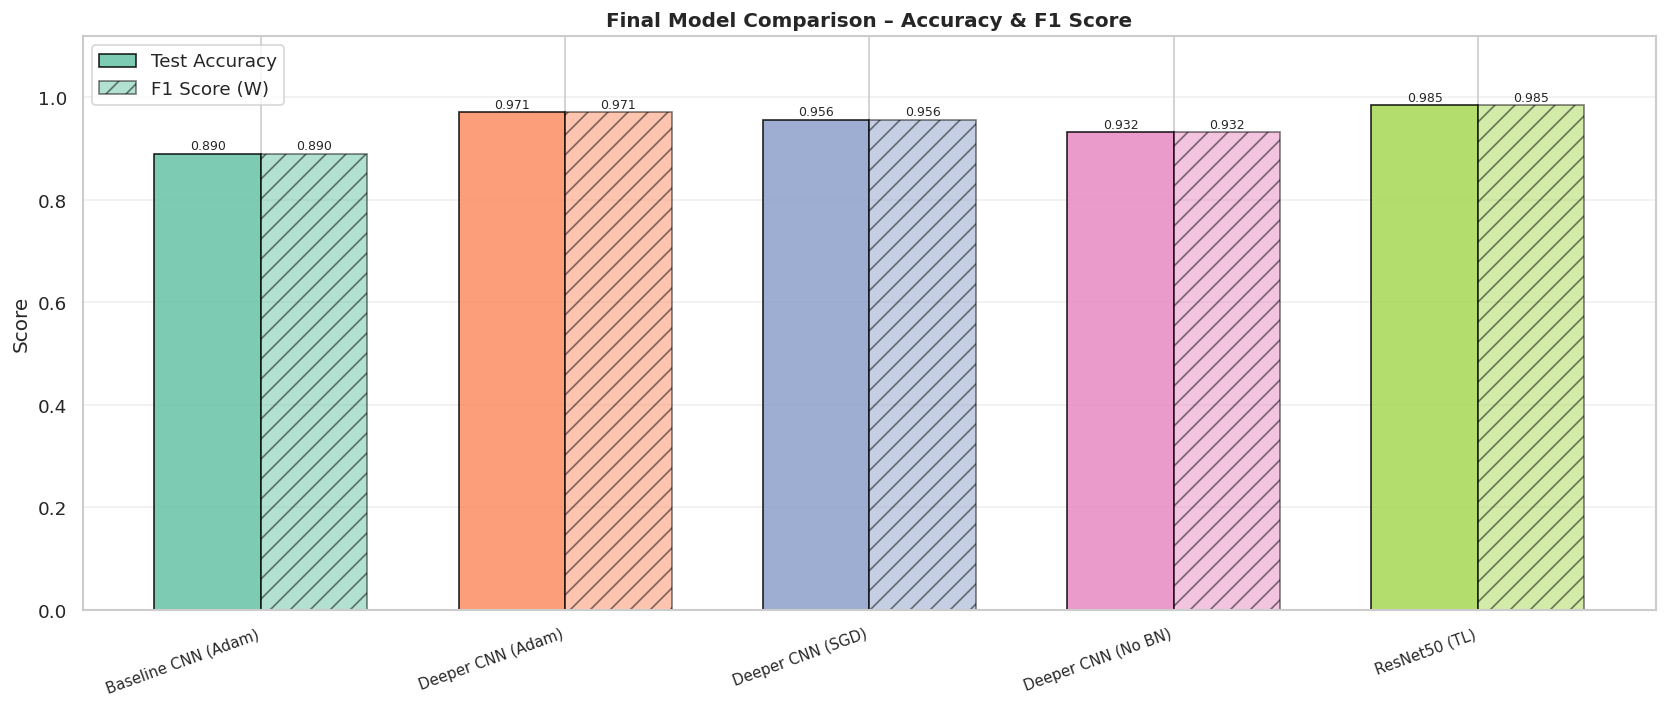

In [32]:
all_models_df = pd.DataFrame({
    'Model' : [
        'Baseline CNN (Adam)',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'Deeper CNN (No BN)',
        'ResNet50 (TL)'
    ],
    'Parameters' : [
        f"{baseline_model.count_params():,}",
        f"{deeper_model.count_params():,}",
        f"{deeper_model.count_params():,}",
        f"{ablation_model.count_params():,}",
        f"{transfer_model.count_params():,}"
    ],
    'Train Time' : [
        f"{baseline_training_time/60:.1f} min",
        f"{deeper_training_time/60:.1f} min",
        f"{sgd_training_time/60:.1f} min",
        f"{ablation_time/60:.1f} min",
        f"{(phase1_time+phase2_time)/60:.1f} min"
    ],
    'Test Acc' : [
        f"{baseline_results['accuracy']*100:.2f}%",
        f"{deeper_results['accuracy']*100:.2f}%",
        f"{sgd_results['accuracy']*100:.2f}%",
        f"{ablation_results['accuracy']*100:.2f}%",
        f"{tl_results['accuracy']*100:.2f}%"
    ],
    'F1 (W)' : [
        f"{baseline_results['f1']:.4f}",
        f"{deeper_results['f1']:.4f}",
        f"{sgd_results['f1']:.4f}",
        f"{ablation_results['f1']:.4f}",
        f"{tl_results['f1']:.4f}"
    ],
    'Precision (W)' : [
        f"{baseline_results['precision']:.4f}",
        f"{deeper_results['precision']:.4f}",
        f"{sgd_results['precision']:.4f}",
        f"{ablation_results['precision']:.4f}",
        f"{tl_results['precision']:.4f}"
    ],
    'Recall (W)' : [
        f"{baseline_results['recall']:.4f}",
        f"{deeper_results['recall']:.4f}",
        f"{sgd_results['recall']:.4f}",
        f"{ablation_results['recall']:.4f}",
        f"{tl_results['recall']:.4f}"
    ]
})

print("\n" + "═"*100)
print("  FINAL COMPREHENSIVE COMPARISON – ALL MODELS")
print("═"*100)
print(all_models_df.to_string(index=False))
print("═"*100)

model_names = all_models_df['Model'].values
accuracies  = [baseline_results['accuracy'], deeper_results['accuracy'],
               sgd_results['accuracy'], ablation_results['accuracy'],
               tl_results['accuracy']]
f1_scores   = [baseline_results['f1'], deeper_results['f1'],
               sgd_results['f1'], ablation_results['f1'],
               tl_results['f1']]

x   = np.arange(len(model_names))
w   = 0.35
pal = sns.color_palette('Set2', len(model_names))

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w/2, accuracies, w, label='Test Accuracy',
               color=[p for p in pal], edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + w/2, f1_scores,  w, label='F1 Score (W)',
               color=[p for p in pal], edgecolor='black', alpha=0.5,
               hatch='//')

for bar, val in zip(list(bars1)+list(bars2), accuracies+f1_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison – Accuracy & F1 Score', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
_buf = __import__('io').BytesIO()
plt.savefig(_buf, format='png', bbox_inches='tight')
_buf.seek(0)
with open('final_comparison.png', 'wb') as _f: _f.write(_buf.read())
plt.show()


In [33]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║  DISCUSSION: Transfer Learning vs. Training from Scratch        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. ACCURACY                                                     ║
║     Transfer learning (ResNet50) consistently outperforms  ║
║     both the baseline and the deeper custom CNNs.                ║
║     Pre-trained features (edges, textures, shapes) learned on    ║
║     ImageNet transfer effectively to satellite land-use classes. ║
║                                                                  ║
║  2. DATA EFFICIENCY                                              ║
║     The frozen base extracts rich features even with limited     ║
║     training data. Phase 1 achieves strong accuracy with only    ║
║     the head trained.                                            ║
║                                                                  ║
║  3. TRAINING TIME                                                ║
║     Phase 1 (feature extraction) is very fast — only the small   ║
║     head is updated. Phase 2 (fine-tuning) adds cost but yields  ║
║     the final accuracy gain.                                     ║
║                                                                  ║
║  4. CATASTROPHIC FORGETTING                                      ║
║     Mitigated by using a very low LR (1e-5) in Phase 2 and by   ║
║     keeping early convolutional layers frozen.                   ║
║                                                                  ║
║  5. CONCLUSION                                                   ║
║     Transfer learning is the recommended approach for EuroSAT    ║
║     given its superior accuracy, faster convergence, and lower   ║
║     data requirements compared to training from scratch.         ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║  DISCUSSION: Transfer Learning vs. Training from Scratch        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. ACCURACY                                                     ║
║     Transfer learning (ResNet50) consistently outperforms  ║
║     both the baseline and the deeper custom CNNs.                ║
║     Pre-trained features (edges, textures, shapes) learned on    ║
║     ImageNet transfer effectively to satellite land-use classes. ║
║                                                                  ║
║  2. DATA EFFICIENCY                                              ║
║     The frozen base extracts rich features even with limited     ║
║     training data. Phase 1 achieves strong accuracy with only    ║
║     the head trained.                                            ║
║                                       

In [34]:
baseline_model.save_weights('baseline_cnn_final.weights.h5')
deeper_model.save_weights('deeper_cnn_final.weights.h5')
transfer_model.save_weights('resnet50_tl_final.weights.h5')

print("    Model weights saved:")
print("   baseline_cnn_final.weights.h5")
print("   deeper_cnn_final.weights.h5")
print("   resnet50_tl_final.weights.h5")

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
loaded = tf.keras.Model(inputs, outputs)
loaded.load_weights('resnet50_tl_final.weights.h5')
loaded.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
loss, acc = loaded.evaluate(test_tl, verbose=0)
print(f"\n   Loaded TL model test accuracy: {acc*100:.2f}%  ")


    Model weights saved:
   baseline_cnn_final.weights.h5
   deeper_cnn_final.weights.h5
   resnet50_tl_final.weights.h5

   Loaded TL model test accuracy: 98.52%  


## Conclusion

For EuroSAT image classification, the baseline CNN gave a reasonable starting result, but the deeper regularised CNN improved performance clearly. Batch Normalization was important in the deeper model, because removing it reduced accuracy from 97.07% to 93.19%.

The best model was the fine-tuned ResNet50 transfer-learning model with 98.52% test accuracy. The main trade-off is training cost: ResNet50 gave the best accuracy, but it took much longer to train than the models built from scratch. If speed and simplicity matter, the deeper CNN is a good option; if maximum accuracy matters, the fine-tuned ResNet50 is better.
